# **Project "Wings of Help"**

The Wings of Help web service is designed to establish effective interaction between users and organizations in need of help and volunteers through a centralized web platform for managing requests for help. The system is designed as an MVP with an orientation towards quick launch and further scalability.
The dataset for the project is created using the Python programming language and meets the database structure and all the basic requirements specified in the documents, including KPIs and metrics.

The "Wings Of Help" dataset consists of 4 tables:
- help_categories.csv;
- users.csv;
- help.csv;
- events.csv.

# **1. Exploratory Data Analysis (EDA) of the "Wings of Help" Dataset**

## **1.1. Data Collection, Data Wrangling and Descriptive Statistics**

### **1.1.1. Connect to Google Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### **1.1.2. Importing necessary libraries**

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## **1.2. Loading the Dataset**

### **1.2.1. Dataset processing - help_categories.csv**

In [ ]:
# Check if files exist

os.listdir("/content")

['.config', 'drive', 'sample_data']

In [ ]:
path = "/content/drive/My Drive/Team Project #211/SP2-SP3/help_categories.csv"
help_categories_df = pd.read_csv(path)

help_categories_df.head()

,id,name
0,1,Evacuation / Relocation
1,2,Medical Support
2,3,Shelter / Housing
3,4,Food & Basic Supplies
4,5,Logistics / Transportation


For convenience, we will hide the index for the 'help_categories_df' table.

In [ ]:
# Hide the index
help_categories_df.style.hide(axis="index")

id,name
1,Evacuation / Relocation
2,Medical Support
3,Shelter / Housing
4,Food & Basic Supplies
5,Logistics / Transportation
6,Psychological Support
7,Child & Family Support
8,Legal / Administrative Assistance
9,Employment / Livelihoods
10,Education / Tutoring


So, remember, the index starts with 0, and the id starts with 1.

In [ ]:
help_categories_df.loc[11]

,11
id,12
name,Animal / Pet Assistance


In [ ]:
# Rename the column "name" to "category"
help_categories_df = help_categories_df.rename(columns={'name': 'category'})

In [ ]:
# Data types in a dataset
help_categories_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        13 non-null     int64 
 1   category  13 non-null     object
dtypes: int64(1), object(1)
memory usage: 340.0+ bytes


In [ ]:
# Number of rows and columns in the table
rows, cols = help_categories_df.shape
print("Rows:", rows)
print("Columns:", cols)

Rows: 13
Columns: 2


In [ ]:
# View categories
sorted(help_categories_df['category'].unique())

['Animal / Pet Assistance',
 'Child & Family Support',
 'Education / Tutoring',
 'Employment / Livelihoods',
 'Evacuation / Relocation',
 'Food & Basic Supplies',
 'Legal / Administrative Assistance',
 'Logistics / Transportation',
 'Medical Support',
 'Other',
 'Psychological Support',
 'Shelter / Housing',
 'Volunteer Coordination / Community Support']

In [ ]:
# Checking duplicates
help_categories_df.duplicated().sum()

np.int64(0)

So, the table has 2 columns, 13 rows, and 13 categories of help requests. The data is recognized correctly, there are no duplicates.

### **1.2.2. Dataset processing - help.csv**

In [ ]:
path = "/content/drive/My Drive/Team Project #211/SP2-SP3/help.csv"
help_df = pd.read_csv(path)

help_df.head()

,id,title,location,description,kind,category_id,status,creator_id,counterpart_id,created_at,completed_at
0,1,Shelter Needed for Two Weeks,Bila Tserkva,Request in Bila Tserkva. Group online therapy ...,request,3,done,121,100.0,2025-11-28T15:41:51.497101+00:00,2026-01-09T22:08:27.497101+00:00
1,2,Pet Food Needed for Displaced Family,Pokrovsk,Available to help on weekends and evenings. Ca...,offer,12,new,414,NaN,2026-01-10T21:10:43.497101+00:00,NaN
2,3,Urgent Food Packages Needed for Displaced Seniors,Odesa,Request in Odesa. Family of five displaced fro...,request,4,new,97,NaN,2026-01-01T00:06:02.497101+00:00,NaN
3,4,Temporary Housing Needed for Mother and Child,Cherkasy,Request in Cherkasy. Two children (ages 1 and ...,request,3,in_progress,132,414.0,2025-12-26T11:38:25.497101+00:00,NaN
4,5,Homework Help Needed for School Child,Kryvyi Rih,Available to help on weekends and evenings. Ca...,offer,10,new,476,NaN,2026-01-24T23:34:29.497101+00:00,NaN


For convenience, let's leave the id available for logic, and hide the index for the 'help_df' table.

In [ ]:
# Hide the index
help_df.head(4).style.hide(axis="index")

id,title,location,description,kind,category_id,status,creator_id,counterpart_id,created_at,completed_at
1,Shelter Needed for Two Weeks,Bila Tserkva,Request in Bila Tserkva. Group online therapy sessions needed for teenagers affected by war-related stress. A family of three with a 4-year-old child needs evacuation from frontline area. Limited belongings. Assistance required urgently.,request,3,done,121,100.000000,2025-11-28T15:41:51.497101+00:00,2026-01-09T22:08:27.497101+00:00
2,Pet Food Needed for Displaced Family,Pokrovsk,Available to help on weekends and evenings. Can travel within the city. Location: Pokrovsk.,offer,12,new,414,nan,2026-01-10T21:10:43.497101+00:00,nan
3,Urgent Food Packages Needed for Displaced Seniors,Odesa,Request in Odesa. Family of five displaced from Donetsk region needs food and basic hygiene supplies. An elderly woman (72) is looking for temporary housing for one month. No special medical needs.,request,4,new,97,nan,2026-01-01T00:06:02.497101+00:00,nan
4,Temporary Housing Needed for Mother and Child,Cherkasy,Request in Cherkasy. Two children (ages 1 and 3). Adult male requires assistance with medications for chronic heart condition. Regular supply needed.,request,3,in_progress,132,414.000000,2025-12-26T11:38:25.497101+00:00,nan


So, remember, the index starts with 0, and the id starts with 1.

In [ ]:
help_df.loc[3]

,3
id,4
title,Temporary Housing Needed for Mother and Child
location,Cherkasy
description,Request in Cherkasy. Two children (ages 1 and ...
kind,request
category_id,3
status,in_progress
creator_id,132
counterpart_id,414.0
created_at,2025-12-26T11:38:25.497101+00:00


In [ ]:
# Number of rows and columns in the dataset
rows, cols = help_df.shape
print("Rows:", rows)
print("Columns:", cols)

Rows: 2000
Columns: 11


The table 'help_df' contains 2000 rows and 11 columns.

In [ ]:
# Rename the column "location" to "city"
help_df = help_df.rename(columns={'location': 'city'})

In [ ]:
# Data types in a dataset
help_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              2000 non-null   int64  
 1   title           2000 non-null   object 
 2   city            2000 non-null   object 
 3   description     2000 non-null   object 
 4   kind            2000 non-null   object 
 5   category_id     2000 non-null   int64  
 6   status          2000 non-null   object 
 7   creator_id      2000 non-null   int64  
 8   counterpart_id  701 non-null    float64
 9   created_at      2000 non-null   object 
 10  completed_at    444 non-null    object 
dtypes: float64(1), int64(3), object(7)
memory usage: 172.0+ KB


In [ ]:
# Checking column types 'created_at', 'completed_at'
print(help_df[['created_at', 'completed_at']].dtypes)

created_at      object
completed_at    object
dtype: object


Convert the object type to the correct data type for date and time columns.

In [ ]:
# Change the data type of the corresponding columns
help_df['created_at'] = pd.to_datetime(help_df['created_at'], utc=True)
help_df['completed_at'] = pd.to_datetime(help_df['completed_at'], utc=True)

In [ ]:
# Checking column type
help_df[['created_at', 'completed_at']].dtypes

,0
created_at,"datetime64[ns, UTC]"
completed_at,"datetime64[ns, UTC]"


We will also change the data type of counterpart_id from float64 to int64. Since this is a key field, it should not have a fractional type; however, pandas often infers float64 due to the presence of NaN values. These NaNs are expected, as not all requests have been processed yet, and therefore not all rows currently have an assigned counterpart.

In [ ]:
help_df['counterpart_id'] = help_df['counterpart_id'].astype('Int64')

In [ ]:
help_df.tail(3)

,id,title,city,description,kind,category_id,status,creator_id,counterpart_id,created_at,completed_at
1997,1998,Homework Help Needed for School Child,Izium,I have experience and resources to assist. Con...,offer,10,new,217,<NA>,2026-01-22 20:31:51.497101+00:00,NaT
1998,1999,Support Needed for Benefit Application,Kryvyi Rih,"Request in Kryvyi Rih. Limited mobility, minim...",request,8,new,463,<NA>,2025-12-14 17:11:38.497101+00:00,NaT
1999,2000,Basic Groceries Needed After Relocation,Bila Tserkva,Request in Bila Tserkva. A family of three wit...,request,4,done,327,87,2026-01-16 14:58:00.497101+00:00,2026-01-26 18:57:49.497101+00:00


In [ ]:
# Checking duplicates
help_df.duplicated().sum()

np.int64(0)

No duplicates were found in the dataset 'help_df'.

In [ ]:
# Generate descriptive statistics for all categorical columns
help_df.describe(include='object')

,title,city,description,kind,status
count,2000,2000,2000,2000,2000
unique,56,32,1543,2,3
top,Basic Groceries Needed After Relocation,Kryvyi Rih,I have experience and resources to assist. Con...,request,new
freq,50,82,9,1504,1299


The help_df dataset has 2000 records in each categorical column. The ad titles have relatively little diversity (56 unique), while the descriptions are very diverse (1543 unique). There are 32 cities, with Kryvyi Rih being the most common. The 'kind' column has 2 values ​​- request/offer. 'Status' - can have 3 states ('new', 'in_progress', and 'done'). The vast majority of records have the type request (1504) and the status 'new' (1299), indicating the dominance of new help requests.

### **1.2.3. Dataset processing - user.csv**

In [ ]:
path = "/content/drive/My Drive/Team Project #211/SP2-SP3/users.csv"
users_df = pd.read_csv(path)

users_df.head()

,id,email,phone_number,first_name,last_name,password,role,date_joined
0,1,kateryna.shevchenko1@bigmir.net,380664108603,Kateryna,Shevchenko,hashed_password_placeholder,admin,2025-09-20T16:01:03.391259
1,2,andrii.sviridenko2@bigmir.net,380921458591,Andrii,Sviridenko,hashed_password_placeholder,distressed,2025-11-30T23:40:29.391259
2,3,anastasia.shevchenko3@ukr.net,380508478454,Anastasia,Shevchenko,hashed_password_placeholder,distressed,2025-12-03T05:23:27.391259
3,4,sophia.ivanchenko4@bigmir.net,380927038374,Sophia,Ivanchenko,hashed_password_placeholder,distressed,2025-09-20T03:06:28.391259
4,5,daria.klimenko5@gmail.com,380977090293,Daria,Klimenko,hashed_password_placeholder,distressed,2025-10-13T09:27:45.391259


For convenience, we will hide the index for the 'users_df' table.

In [ ]:
# Hide the index
users_df.head(4).style.hide(axis="index")

id,email,phone_number,first_name,last_name,password,role,date_joined
1,kateryna.shevchenko1@bigmir.net,380664108603,Kateryna,Shevchenko,hashed_password_placeholder,admin,2025-09-20T16:01:03.391259
2,andrii.sviridenko2@bigmir.net,380921458591,Andrii,Sviridenko,hashed_password_placeholder,distressed,2025-11-30T23:40:29.391259
3,anastasia.shevchenko3@ukr.net,380508478454,Anastasia,Shevchenko,hashed_password_placeholder,distressed,2025-12-03T05:23:27.391259
4,sophia.ivanchenko4@bigmir.net,380927038374,Sophia,Ivanchenko,hashed_password_placeholder,distressed,2025-09-20T03:06:28.391259


So, remember, the index starts with 0, and the id starts with 1.

In [ ]:
users_df.loc[3]

,3
id,4
email,sophia.ivanchenko4@bigmir.net
phone_number,380927038374
first_name,Sophia
last_name,Ivanchenko
password,hashed_password_placeholder
role,distressed
date_joined,2025-09-20T03:06:28.391259


In [ ]:
# Number of rows and columns in the table
rows, cols = users_df.shape
print("Rows:", rows)
print("Columns:", cols)

Rows: 500
Columns: 8


The table 'users_df' contains 500 rows and 8 columns.

In [ ]:
# Data types in a dataset
users_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            500 non-null    int64 
 1   email         500 non-null    object
 2   phone_number  500 non-null    int64 
 3   first_name    500 non-null    object
 4   last_name     500 non-null    object
 5   password      500 non-null    object
 6   role          500 non-null    object
 7   date_joined   500 non-null    object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


All data types are correctly defined in the 'users_df' table, except for the date_joined field. This stores the date the user created the account, so сonvert the object type to the correct data type for date and time columns.

In [ ]:
# Change the data type of the corresponding columns
users_df['date_joined'] = pd.to_datetime(users_df['date_joined'], utc=True)

In [ ]:
# Checking column type
users_df['date_joined'].dtypes

datetime64[ns, UTC]

In [ ]:
# Checking duplicates
users_df.duplicated().sum()

np.int64(0)

No duplicates were found in this table.

In [ ]:
# Generate descriptive statistics for all categorical columns
users_df.describe(include='object')

,email,first_name,last_name,password,role
count,500,500,500,500,500
unique,500,16,13,1,3
top,anastasia.melnyk500@ukr.net,Andrii,Koval,hashed_password_placeholder,distressed
freq,1,41,54,500,340


So, there are 500 users in the 'users_df' table. All email addresses are unique, which indicates correct user identification.   
First names and last names have low diversity (16 first names and 13 last names), with the most common first name being Andrii and last name being Koval.   
The password field has one unique value (stub), and the user role 'distressed' dominates among users (340 records out of 500), which indicates a significant need for help.

### **1.2.4. Dataset processing - events.csv**

In [ ]:
path = "/content/drive/My Drive/Team Project #211/SP2-SP3/events.csv"
events_df = pd.read_csv(path)

events_df.head()

,event_id,event_name,occurred_at,user_id,user_role,help_id,kind,category_id,location,status,old_status,new_status,counterpart_id,results_count,entry_point,cta_location,error_type,channel,delivery_status,failure_reason
0,1,request_form_started,2026-01-13T08:52:18.497101+00:00,171,distressed,NaN,request,9,Melitopol,NaN,NaN,NaN,NaN,NaN,home,NaN,NaN,NaN,NaN,NaN
1,2,request_form_submitted,2026-01-13T08:58:49.497101+00:00,171,distressed,NaN,request,9,Melitopol,NaN,NaN,NaN,NaN,NaN,home,NaN,abandoned,NaN,NaN,NaN
2,3,request_form_started,2025-12-25T09:30:44.497101+00:00,68,distressed,NaN,request,10,Marinka,NaN,NaN,NaN,NaN,NaN,home,NaN,NaN,NaN,NaN,NaN
3,4,request_form_submitted,2025-12-25T09:33:10.497101+00:00,68,distressed,NaN,request,10,Marinka,NaN,NaN,NaN,NaN,NaN,home,NaN,abandoned,NaN,NaN,NaN
4,5,request_form_started,2025-12-18T13:21:49.497101+00:00,291,distressed,NaN,request,2,Dnipro,NaN,NaN,NaN,NaN,NaN,home,NaN,NaN,NaN,NaN,NaN


For convenience, we will hide the index for the 'events_df' table.


In [ ]:
# Hide the index
events_df.head(4).style.hide(axis='index')

event_id,event_name,occurred_at,user_id,user_role,help_id,kind,category_id,location,status,old_status,new_status,counterpart_id,results_count,entry_point,cta_location,error_type,channel,delivery_status,failure_reason
1,request_form_started,2026-01-13T08:52:18.497101+00:00,171,distressed,nan,request,9,Melitopol,nan,nan,nan,nan,nan,home,nan,nan,nan,nan,nan
2,request_form_submitted,2026-01-13T08:58:49.497101+00:00,171,distressed,nan,request,9,Melitopol,nan,nan,nan,nan,nan,home,nan,abandoned,nan,nan,nan
3,request_form_started,2025-12-25T09:30:44.497101+00:00,68,distressed,nan,request,10,Marinka,nan,nan,nan,nan,nan,home,nan,nan,nan,nan,nan
4,request_form_submitted,2025-12-25T09:33:10.497101+00:00,68,distressed,nan,request,10,Marinka,nan,nan,nan,nan,nan,home,nan,abandoned,nan,nan,nan


So, remember, the index starts with 0, and the id starts with 1.

In [ ]:
print(events_df.loc[48])

event_id                                         49
event_name                     request_form_started
occurred_at        2025-12-14T00:46:27.497101+00:00
user_id                                         259
user_role                                distressed
help_id                                         NaN
kind                                        request
category_id                                      10
location                                   Ternopil
status                                          NaN
old_status                                      NaN
new_status                                      NaN
counterpart_id                                  NaN
results_count                                   NaN
entry_point                                    home
cta_location                                    NaN
error_type                                      NaN
channel                                         NaN
delivery_status                                 NaN
failure_reas

In [ ]:
# Rename the column "location" to "city"
events_df = events_df.rename(columns={'location': 'city'})

In [ ]:
# Number of rows and columns in the dataset
rows, cols = events_df.shape
print("Rows:", rows)
print("Columns:", cols)

Rows: 9510
Columns: 20


The table contains 9510 rows and 20 columns.

In [ ]:
events_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9510 entries, 0 to 9509
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   event_id         9510 non-null   int64  
 1   event_name       9510 non-null   object 
 2   occurred_at      9510 non-null   object 
 3   user_id          9510 non-null   int64  
 4   user_role        9510 non-null   object 
 5   help_id          5030 non-null   float64
 6   kind             9510 non-null   object 
 7   category_id      9510 non-null   int64  
 8   city             9510 non-null   object 
 9   status           3899 non-null   object 
 10  old_status       1131 non-null   object 
 11  new_status       1131 non-null   object 
 12  counterpart_id   2896 non-null   float64
 13  results_count    0 non-null      float64
 14  entry_point      5868 non-null   object 
 15  cta_location     1388 non-null   object 
 16  error_type       240 non-null    object 
 17  channel       

Convert the "occurred_at" field from an object type to the correct data type for date and time columns.

In [ ]:
# Change the data type of the corresponding columns
events_df['occurred_at'] = pd.to_datetime(events_df['occurred_at'], utc=True)

In [ ]:
# Checking column type
events_df['occurred_at'].dtypes

datetime64[ns, UTC]

Let's also change the data type of 'help_id', 'counterpart_id' from float64 to int64. Since these are key fields and they should not have a fractional type. However, pandas often determines float64 in the key field due to the presence of NaN values. These NaNs are expected because not all queries have been processed yet, and therefore not all rows currently have an assigned match.

In [ ]:
events_df[['help_id','counterpart_id']] = events_df[['help_id','counterpart_id']].astype('Int64')

In [ ]:
events_df[['help_id','counterpart_id']].dtypes

,0
help_id,Int64
counterpart_id,Int64


In [ ]:
# Checking duplicates
events_df.duplicated().sum()

np.int64(0)

No duplicates were found in the table 'events_df'.

In [ ]:
# Generate descriptive statistics for all categorical columns
events_df.describe(include='object')

,event_name,user_role,kind,city,status,old_status,new_status,entry_point,cta_location,error_type
count,9510,9510,9510,9510,3899,1131,1131,5868,1388,240
unique,12,2,2,32,3,2,3,4,2,2
top,request_form_started,distressed,request,Pokrovsk,new,new,in_progress,home,help_card,abandoned
freq,1744,4992,7948,407,2761,694,694,3488,694,162


The table contains 9510 events, including 12 different event types, the most common of which is request_form_started. The events are mostly initiated by users with the role 'distressed' and the request type 'request'. The most common city is Pokrovsk, the status is 'new', and the transition is 'in progress'. The main entry point is home, the call to action is help_card, and the type 'abandoned' dominates among the errors, which may indicate that users are interrupting the interaction process.

## **1.3. Missing Value Treatment, Outliers and Frequency-based Checks**

The specificity of "Wings of Help" project data indicates that the dataset is predominantly categorical, while numerical data is mainly used in key fields. Therefore, investigating outliers is not advisable, as outliers are a concept applicable to numerical data. Instead, for categorical variables, frequency-based checks should be performed, which serve as a functional analogue to outlier detection.

### **1.3.1. Analysis of Missing Values and Frequency-based Checks in the 'help_categories' Table**

In [ ]:
# Checking the number of invalid or missing dates in column 'category'.
print(help_categories_df['category'].isna().sum())

0


In [ ]:
# View categories
help_categories_df['category'].unique()

array(['Evacuation / Relocation', 'Medical Support', 'Shelter / Housing',
       'Food & Basic Supplies', 'Logistics / Transportation',
       'Psychological Support', 'Child & Family Support',
       'Legal / Administrative Assistance', 'Employment / Livelihoods',
       'Education / Tutoring',
       'Volunteer Coordination / Community Support',
       'Animal / Pet Assistance', 'Other'], dtype=object)

The 'help_categories_df' table contains only category names, a total of 13 different categories. The id categories are used in other tables to build the query.

### **1.3.2. Analysis of Missing Values and Outliers in the 'help_df' Table**

In [ ]:
#The 'help_id' table
help_df.head(3).style.hide(axis='index')

id,title,city,description,kind,category_id,status,creator_id,counterpart_id,created_at,completed_at
1,Shelter Needed for Two Weeks,Bila Tserkva,Request in Bila Tserkva. Group online therapy sessions needed for teenagers affected by war-related stress. A family of three with a 4-year-old child needs evacuation from frontline area. Limited belongings. Assistance required urgently.,request,3,done,121,100,2025-11-28 15:41:51.497101+00:00,2026-01-09 22:08:27.497101+00:00
2,Pet Food Needed for Displaced Family,Pokrovsk,Available to help on weekends and evenings. Can travel within the city. Location: Pokrovsk.,offer,12,new,414,,2026-01-10 21:10:43.497101+00:00,NaT
3,Urgent Food Packages Needed for Displaced Seniors,Odesa,Request in Odesa. Family of five displaced from Donetsk region needs food and basic hygiene supplies. An elderly woman (72) is looking for temporary housing for one month. No special medical needs.,request,4,new,97,,2026-01-01 00:06:02.497101+00:00,NaT


In [ ]:
# NaN
print(f'Number of missing values:\n{help_df.isna().sum()}')
print('------------------------')

# Empty lines
print(f'Number of empty lines:\n{(help_df == "").sum()}')
print('-----------------------')

# Pseudo-misses
print(f'Number of pseudo-misses:\n{help_df.isin(["null", "None", "NA", "N/A"]).sum()}')

Number of missing values:
id                   0
title                0
city                 0
description          0
kind                 0
category_id          0
status               0
creator_id           0
counterpart_id    1299
created_at           0
completed_at      1556
dtype: int64
------------------------
Number of empty lines:
id                0
title             0
city              0
description       0
kind              0
category_id       0
status            0
creator_id        0
counterpart_id    0
created_at        0
completed_at      0
dtype: Int64
-----------------------
Number of pseudo-misses:
id                0
title             0
city              0
description       0
kind              0
category_id       0
status            0
creator_id        0
counterpart_id    0
created_at        0
completed_at      0
dtype: Int64


There are missing values ​​in the counterpart_id - 1299 and completed_at - 1556 columns. Missing values ​​indicate that the requests have not yet been accepted by volunteers, i.e. they have a status of "new" and are incomplete. Therefore, missing values ​​here are not an error, but indicate that the requests have not yet been processed and completed.

In [ ]:
# Rare categories help_df
help_df['category_id'].value_counts(normalize=True)

,proportion
category_id,
3,0.0915
13,0.0825
4,0.0805
12,0.0790
10,0.0785
5,0.0785
7,0.0775
9,0.0755
6,0.0755


The distribution of 'category_id' is fairly even: the category shares range from approximately 6.6% to 9.2%. There are no clearly rare categories, as no category has a critically small share. Thus, the imbalance between categories is minimal, and all categories are sufficiently represented for further analysis or modeling.

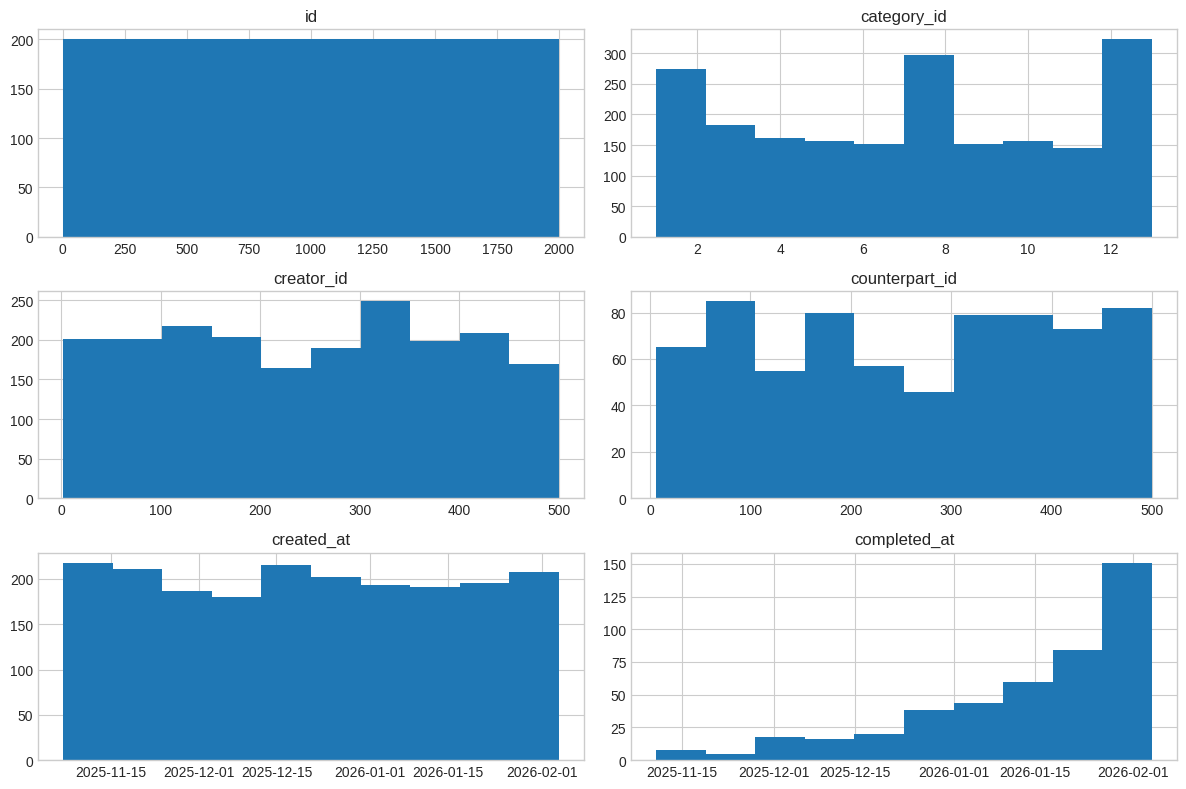

In [ ]:
# Constructing histograms to determine the shape of the distribution
plt.style.use("seaborn-v0_8-whitegrid")

help_df.hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

Most of the numeric and identification variables (category_id, creator_id, counterpart_id) have a close to uniform distribution without pronounced skews or anomalous peaks. Events were created evenly in time (created_at) throughout the period. At the same time, completed_at has a shift towards later dates, which indicates an accumulation of processed requests closer to the end of the observation period.

In [ ]:
# Status distribution
help_df["status"].value_counts(normalize=True)

,proportion
status,
new,0.6495
done,0.2220
in_progress,0.1285


The distribution of statuses is unbalanced, with the majority of records having the status "new" (65%), indicating a significant number of new or not yet processed requests. The status "done" is 22%, and "in_progress" is only 12.9%, which may indicate a slow transition of requests to active work or completion.

In [ ]:
# Check if logical combinations
pd.crosstab(help_df["kind"], help_df["status"], normalize="index")

status,done,in_progress,new
kind,,,
offer,0.149194,0.000000,0.850806
request,0.246011,0.170878,0.583112


For the proposal type, almost all records have the status "new" (≈85%), and the status "in_progress" is absent, which means that proposals have a different processing logic than requests. For the request, there is a more balanced distribution of statuses with a transition to "in_progress" and "done", which is logical for requests for help.

Checking the analogue of "outliers" for categories, in particular, we will check what proportion of counterpart_id is by status.
It is expected that if:
- 'new' has counterpart_id, then - this is a logical error;
- 'done' without counterpart_id, then the data is incorrect.

In [ ]:
# Share counterpart_id by status
help_df.assign(
    has_counterpart=help_df["counterpart_id"].notna()
).groupby("status")["has_counterpart"].mean()

,has_counterpart
status,
done,1.0
in_progress,1.0
new,0.0


The check confirmed the logical consistency of the data:
- all records with the statuses done and in_progress have a counterpart_id (proportion = 1.0);
- records with the status new do not have a counterpart_id (proportion = 0.0).  

No logical errors or categorical "outliers" were found in this part of the data.

In [ ]:
# Rare locations (city)
print(help_df["city"].value_counts())

city
Kryvyi Rih         82
Rivne              82
Marinka            80
Pokrovsk           77
Zhytomyr           74
Vinnytsia          72
Ternopil           71
Kharkiv            70
Izium              68
Sumy               63
Lviv               63
Kremenchuk         63
Zaporizhzhia       63
Poltava            61
Kherson            60
Odesa              60
Berdyansk          60
Chernivtsi         60
Mariupol           59
Chernihiv          59
Dnipro             59
Bila Tserkva       59
Mykolaiv           59
Lutsk              58
Kropyvnytskyi      58
Brovary            55
Bakhmut            55
Cherkasy           53
Uzhhorod           52
Kyiv               50
Ivano-Frankivsk    48
Melitopol          47
Name: count, dtype: int64


The distribution of records across cities is even and balanced. The number of observations in each city is in a close range (approximately 47–82). No clearly rare locations or outlier cities were identified, indicating the absence of geographic skew in the data.

Checking for suspicious behavioral outliers, i.e. that one 'creator_id' did not have 40% of all entries.

In [ ]:
# Checking for suspicious behavioral outliers
vc = help_df["creator_id"].value_counts()

outliers = (
    vc
    .to_frame(name="count")
    .assign(share=lambda x: x["count"] / x["count"].sum())
)

outliers.head(10)

,count,share
creator_id,,
301,14,0.0070
363,9,0.0045
188,9,0.0045
18,9,0.0045
78,9,0.0045
315,9,0.0045
168,9,0.0045
167,9,0.0045
269,9,0.0045


There is no evidence of suspicious user behavior. Even the most active 'creator_id' has only 14 entries, which is a very small fraction of the total (0.007). No single user dominates the data or approaches the 40% threshold, so the distribution of activity across users is balanced.

In [ ]:
# Checking the consistency of completed_at in status, and vice versa
help_df.assign(
    has_completed_at=help_df["completed_at"].notna()
).groupby("status")["has_completed_at"].mean()

,has_completed_at
status,
done,1.0
in_progress,0.0
new,0.0


The data is logically consistent: all records with the status 'done' have the completed_at field filled in, while the 'new' and 'in_progress' statuses do not have this field. No discrepancies were found between the status and the completion date.

In [ ]:
pd.crosstab(help_df["status"], help_df["counterpart_id"].notna())

counterpart_id,False,True
status,,
done,0,444
in_progress,0,257
new,1299,0


The table 'help_df' clearly shows full consistency between status and the presence of 'counterpart_id'. All records with statuses 'done' (444) and 'in_progress' (257) have a completed 'counterpart_id'. All records with status 'new' (1299) do not have a 'counterpart_id'.

No logical errors or anomalies were found in the data – the structure corresponds to the expected business logic of "Wings of Help" project.

### **1.3.3. Analysis of Missing Values and Outliers in the 'users_df' Table**

In [ ]:
users_df.head().style.hide(axis='index')

id,email,phone_number,first_name,last_name,password,role,date_joined
1,kateryna.shevchenko1@bigmir.net,380664108603,Kateryna,Shevchenko,hashed_password_placeholder,admin,2025-09-20 16:01:03.391259+00:00
2,andrii.sviridenko2@bigmir.net,380921458591,Andrii,Sviridenko,hashed_password_placeholder,distressed,2025-11-30 23:40:29.391259+00:00
3,anastasia.shevchenko3@ukr.net,380508478454,Anastasia,Shevchenko,hashed_password_placeholder,distressed,2025-12-03 05:23:27.391259+00:00
4,sophia.ivanchenko4@bigmir.net,380927038374,Sophia,Ivanchenko,hashed_password_placeholder,distressed,2025-09-20 03:06:28.391259+00:00
5,daria.klimenko5@gmail.com,380977090293,Daria,Klimenko,hashed_password_placeholder,distressed,2025-10-13 09:27:45.391259+00:00


In [ ]:
# NaN
print(f'Number of missing values:\n{users_df.isna().sum()}')
print('------------------------')

# Empty lines
print(f'Number of empty lines:\n{(users_df == "").sum()}')
print('-----------------------')

# Pseudo-misses
print(f'Number of pseudo-misses:\n{users_df.isin(["null", "None", "NA", "N/A"]).sum()}')

Number of missing values:
id              0
email           0
phone_number    0
first_name      0
last_name       0
password        0
role            0
date_joined     0
dtype: int64
------------------------
Number of empty lines:
id              0
email           0
phone_number    0
first_name      0
last_name       0
password        0
role            0
date_joined     0
dtype: int64
-----------------------
Number of pseudo-misses:
id              0
email           0
phone_number    0
first_name      0
last_name       0
password        0
role            0
date_joined     0
dtype: int64


The 'users_df' table has no missing values, empty lines, or pseudo-misses.

In [ ]:
# Checking the uniqueness of email addresses
users_df['email'].is_unique

True

So, email addresses have been verified and are unique.

Frequency-based verification for a role (distressed, volunteer, admin).

In [ ]:
# Logical role checking
users_df['role'].value_counts(normalize=True)

,proportion
role,
distressed,0.680
volunteer,0.318
admin,0.002


The distribution by roles is expected and logical, as the majority of users have the role 'distressed' (68%), another significant share is volunteer (32%), and admin is minimally represented (0.2%). No signs of anomalous or incorrect distribution by roles were detected.

In [ ]:
users_df['role'].isin(['admin', 'distressed', 'volunteer']).all()

np.True_

The role field passes a logical check, as no values ​​other than 'admin', 'distressed', 'volunteer' were found.

In [ ]:
names_frequency_df = pd.DataFrame({
    "first_name": users_df["first_name"].value_counts().head(5).index,
    "first_name_count": users_df["first_name"].value_counts().head(5).values,
    "last_name": users_df["last_name"].value_counts().head(5).index,
    "last_name_count": users_df["last_name"].value_counts().head(5).values,
})

names_frequency_df

,first_name,first_name_count,last_name,last_name_count
0,Andrii,41,Koval,54
1,Daria,37,Ivanchenko,44
2,Petro,35,Bondarenko,43
3,Vadim,35,Sviridenko,41
4,Oksana,34,Klimenko,40


The most common first and last names have moderate frequencies and do not dominate the sample. For example, even the most common first name (Andrii, 41) and last name (Koval, 54) cover only a small proportion of users. This indicates the absence of anomalies or artificial concentration and a realistic distribution of personal data.

In [ ]:
# Missing values
users_df.isna().mean()

,0
id,0.0
email,0.0
phone_number,0.0
first_name,0.0
last_name,0.0
password,0.0
role,0.0
date_joined,0.0


A percentage of 0% for all columns is the expected value, as the presence of values ​​confirms their completeness. All columns are required for registration, so the presence of NaN is an error.

In [ ]:
(
    users_df["email"].is_unique
    and users_df["phone_number"].is_unique
    and users_df["role"].value_counts().get("admin", 0) == 1
)

np.True_

As a result of the aggregated security check, the uniqueness of users' email addresses and phone numbers was confirmed, as well as the correspondence of their role distribution to business requirements (the presence of only one administrator).

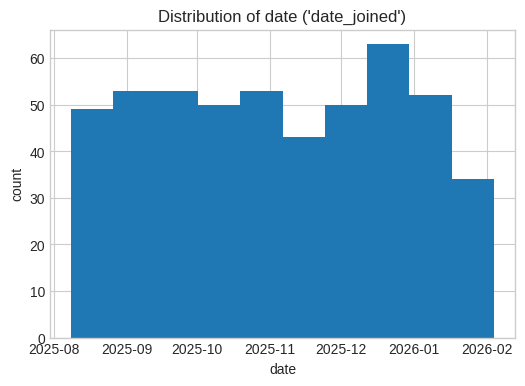

In [ ]:
# Constructing histograms to determine the shape of the distribution
plt.style.use("seaborn-v0_8-whitegrid")

users_df['date_joined'].hist(figsize=(6, 4))
plt.title("Distribution of date ('date_joined')")
plt.xlabel('date')
plt.ylabel('count')
plt.show()

Registration dates (date_joined) are distributed fairly evenly over time without sharp spikes or dips, indicating a stable influx of users during the observation period.

Time period for the 'users_df' table.

In [ ]:
start = users_df['date_joined'].min()
end = users_df['date_joined'].max()

print(f"Data period: from {start.date()} to {end.date()}")
print(f"Duration: {(end - start).days} days.")

Data period: from 2025-08-08 to 2026-02-04
Duration: 179 days.


No logical errors or anomalies were found in the data, the addresses are unique, there are no missing values, so the structure corresponds to the expected business logic of 'Wings of Help' project.

### **1.3.4. Analysis of Missing Values and Outliers in the 'events_df' Table**

In [ ]:
events_df.head(3).style.hide(axis='index')

event_id,event_name,occurred_at,user_id,user_role,help_id,kind,category_id,city,status,old_status,new_status,counterpart_id,results_count,entry_point,cta_location,error_type,channel,delivery_status,failure_reason
1,request_form_started,2026-01-13 08:52:18.497101+00:00,171,distressed,,request,9,Melitopol,nan,nan,nan,,nan,home,nan,nan,nan,nan,nan
2,request_form_submitted,2026-01-13 08:58:49.497101+00:00,171,distressed,,request,9,Melitopol,nan,nan,nan,,nan,home,nan,abandoned,nan,nan,nan
3,request_form_started,2025-12-25 09:30:44.497101+00:00,68,distressed,,request,10,Marinka,nan,nan,nan,,nan,home,nan,nan,nan,nan,nan


In [ ]:
# Distribution event_name
events_df['event_name'].value_counts(normalize=True)

,proportion
event_name,
request_form_started,0.183386
request_form_submitted,0.183386
request_created,0.158149
request_status_changed,0.118927
request_take_attempted,0.072976
request_take_succeeded,0.072976
offer_form_started,0.052156
offer_form_submitted,0.052156
offer_created,0.052156


In [ ]:
# Funnel check: *_started to *_submitted
events_df.query(
    "event_name in ['request_form_started', 'request_form_submitted']"
)["event_name"].value_counts()

,count
event_name,
request_form_started,1744
request_form_submitted,1744


All expected events are present; no names with obvious typos or random events were detected. The share of request_form_started is equal to request_form_submitted (≈18.34%), i.e., there is no violation of the logic submitted > started, although there is no typical "dropout" between these steps, i.e., everyone who started the form filled it out and submitted it, so this is worth taking into account. There are no events with an abnormally small share (~0.1%). Overall, the distribution of event_name is consistent.

Checks how many events ended with an error and whether there are any unexpected error types.

In [ ]:
# Frequency check по error_type
events_df["error_type"].value_counts(dropna=False)

,count
error_type,
NaN,9270
abandoned,162
validation_error,78


A larger number of events (9270) complete without errors (error_type = NaN). Only two types of errors are recorded - abandoned (162) and validation_error (78), which are expected and logical for user scenarios.
In particular:
- abandoned - is an error that indicates that the user interrupted the action on their own (for example, left the form, closed the page, did not complete the started step).
- validation_error - is an error that indicates that the action was stopped due to incorrect data (for example, missing mandatory fields, incorrect format (email, phone, etc.)).


In [ ]:
# Checking event_name × error_type
pd.crosstab(
    events_df["event_name"],
    events_df["error_type"],
    dropna=False,
    normalize="index"
)

error_type,abandoned,validation_error,NaN
event_name,,,
offer_created,0.00000,0.000000,1.000000
offer_form_started,0.00000,0.000000,1.000000
offer_form_submitted,0.00000,0.000000,1.000000
offer_matched,0.00000,0.000000,1.000000
request_completed,0.00000,0.000000,1.000000
request_created,0.00000,0.000000,1.000000
request_declined,0.00000,0.000000,1.000000
request_form_started,0.00000,0.000000,1.000000
request_form_submitted,0.09289,0.044725,0.862385


The error_type field is filled in exclusively for the request_form_submitted event, where logical error types (abandoned, validation_error) are recorded.

For request_form_started and all other events, error_type is always NaN, which confirms the correct logging logic.   
Therefore, there are no signs of erroneous or inconsistent events in the data.

In [ ]:
# Frequency check user_role × event_name
pd.crosstab(events_df["event_name"], events_df["user_role"])

user_role,distressed,volunteer
event_name,,
offer_created,0,496
offer_form_started,0,496
offer_form_submitted,0,496
offer_matched,0,74
request_completed,0,370
request_created,1504,0
request_declined,0,67
request_form_started,1744,0
request_form_submitted,1744,0


The distribution of events by role is strictly logical and consistent.   
Events related to creating and submitting requests are performed exclusively by users with the 'distressed' role, while all actions with suggestions, status changes, and matching are performed only by 'volunteer'.   
No role overlaps or logical violations in the events were detected.

In [ ]:
events_df["help_id"].isna().mean()

np.float64(0.47108307045215564)

The proportion of missing help_id values ​​is ~47%, which is an expected result, since the table contains both events that occur before the request is created (form events) and request lifecycle events for which the help_id already exists.

In [ ]:
pd.crosstab(
    events_df["event_name"],
    events_df["help_id"].isna(),
    normalize="index"
)

help_id,False,True
event_name,,
offer_created,1.0,0.0
offer_form_started,0.0,1.0
offer_form_submitted,0.0,1.0
offer_matched,1.0,0.0
request_completed,1.0,0.0
request_created,1.0,0.0
request_declined,1.0,0.0
request_form_started,0.0,1.0
request_form_submitted,0.0,1.0


The relationship between 'event_name' and the presence of 'help_id'' is completely consistent. This is explained by the fact that events that occur before the entity is created (start and submit forms) correctly do not have 'help_id', while all events after the request or offer is created always contain 'help_id'. No logical violations or anomalies in the association of events with 'help_id' were found.

In [ ]:
# Frequency check по city
print(events_df["city"].value_counts())

city
Pokrovsk           407
Marinka            385
Kryvyi Rih         374
Zhytomyr           373
Vinnytsia          369
Rivne              368
Ternopil           355
Izium              316
Kharkiv            312
Kremenchuk         309
Kherson            309
Sumy               307
Lviv               300
Odesa              293
Bila Tserkva       290
Lutsk              284
Chernivtsi         284
Zaporizhzhia       279
Chernihiv          279
Mariupol           278
Poltava            276
Berdyansk          275
Dnipro             275
Brovary            269
Kropyvnytskyi      266
Cherkasy           266
Uzhhorod           257
Bakhmut            247
Mykolaiv           247
Kyiv               238
Melitopol          219
Ivano-Frankivsk    204
Name: count, dtype: int64


The distribution of events by city is uniform and stable. This is explained by the stable number of events in each city. There is no dominance of individual cities, and all locations have a sufficient number of events, which indicates the absence of geographical anomalies and correct data coverage.

In [ ]:
# Frequency check by 'category_id'
print(events_df["category_id"].value_counts())

category_id
3     910
4     786
13    777
5     756
10    745
12    739
7     718
8     718
6     695
2     684
9     677
11    671
1     634
Name: count, dtype: int64


The distribution of events by category_id is fairly even, as the number of events in the categories fluctuates in a close range (≈630–910). No category is critically dominant or significantly underrepresented, indicating the absence of categorical anomalies in the data.

In [ ]:
# NaN
print(f'Number of missing values:\n{events_df.isna().sum().sort_values(ascending=False)}')
print('------------------------')

# Empty lines
print(f'Number of empty lines:\n{(events_df == "").sum()}')
print('-----------------------')

# Pseudo-misses
print(f'Number of pseudo-misses:\n{events_df.isin(["null", "None", "NA", "N/A"]).sum()}')

Number of missing values:
results_count      9510
failure_reason     9510
delivery_status    9510
channel            9510
error_type         9270
old_status         8379
new_status         8379
cta_location       8122
counterpart_id     6614
status             5611
help_id            4480
entry_point        3642
user_id               0
occurred_at           0
event_name            0
event_id              0
city                  0
user_role             0
kind                  0
category_id           0
dtype: int64
------------------------
Number of empty lines:
event_id           0
event_name         0
occurred_at        0
user_id            0
user_role          0
help_id            0
kind               0
category_id        0
city               0
status             0
old_status         0
new_status         0
counterpart_id     0
results_count      0
entry_point        0
cta_location       0
error_type         0
channel            0
delivery_status    0
failure_reason     0
dtype: Int64


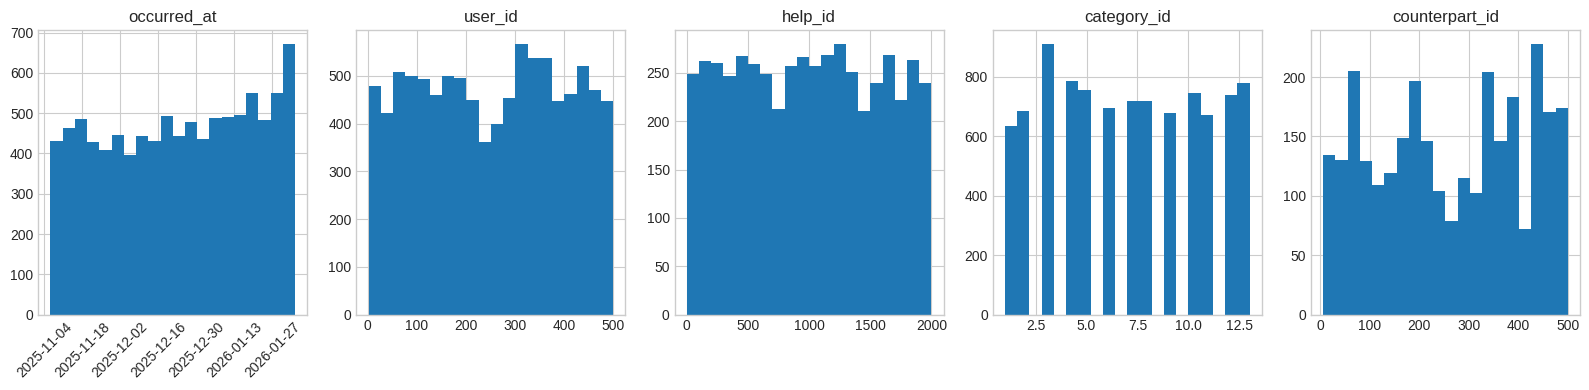

In [ ]:
import matplotlib.dates as mdates
plt.style.use("seaborn-v0_8-whitegrid")

events_df["occurred_at"] = pd.to_datetime(events_df["occurred_at"])

fig, axes = plt.subplots(1, 5, figsize=(16, 4))

cols = ["occurred_at", "user_id", "help_id", "category_id", "counterpart_id"]

for ax, col in zip(axes, cols):
    events_df[col].dropna().hist(ax=ax, bins=20)
    ax.set_title(col)

# Format data
axes[0].xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
axes[0].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

All variables have an expected and stable distribution. Events ('occurred_at') occur evenly over time without any sharp anomalies. Identifiers ('user_id', 'help_id', 'counterpart_id') are evenly distributed, with no dominance of individual values, indicating the absence of behavioral outliers. Field of 'category_id' also has no critical skews, meaning all categories are well represented.

The events table is a generic event log table, so most of the columns are only applicable to specific types of events. So, we will not handle missing values, because NaN means “not relevant to this event”, not “missing data”.

## **2. Calculating key metrics**

## **2.1. Basic metrics**

In [ ]:
# Filter
requests = help_df[help_df["kind"].eq("request")].copy()
offers = help_df[help_df["kind"].eq("offer")].copy()

# Status
total_requests = len(requests)
total_offers = len(offers)
new_requests = requests["status"].eq("new").sum()
in_progress_requests = requests["status"].eq("in_progress").sum()
done_requests = requests["status"].eq("done").sum()

# Time to completion only for done
requests["created_at"] = pd.to_datetime(requests["created_at"], errors="coerce", utc=True)
requests["completed_at"] = pd.to_datetime(requests["completed_at"], errors="coerce", utc=True)

done_only = requests[requests["status"].eq("done") & requests["completed_at"].notna()].copy()
done_only["time_to_complete"] = done_only["completed_at"] - done_only["created_at"]

avg_time_to_complete = done_only["time_to_complete"].mean()

# % done
pct_done = (done_requests / total_requests) if total_requests else 0

# Output metrics
metrics = pd.DataFrame([{
    "total_requests": total_requests,
    "total_offers": total_offers,
    "new_requests": int(new_requests),
    "in_progress_requests": int(in_progress_requests),
    "done_requests": int(done_requests),
    "avg_time_to_complete": avg_time_to_complete,
    "avg_time_to_complete_hours": (
        avg_time_to_complete.total_seconds() / 3600
        if pd.notna(avg_time_to_complete) else None
    ),
    "pct_done": round(pct_done * 100, 2),
}])

metrics

,total_requests,total_offers,new_requests,in_progress_requests,done_requests,avg_time_to_complete,avg_time_to_complete_hours,pct_done
0,1504,496,877,257,370,23 days 06:28:48.008108108,558.480002,24.6


## **2.2. Request Creation KPIs**

### **2.2.1. Requests Created**

The number of help requests successfully created by users during the selected time period (for which the request_created event was recorded)

In [ ]:
# How many unique help_ids?
unique_requests = events_df[
    (events_df["event_name"] == "request_created") &
    (events_df["kind"] == "request")
]["help_id"].nunique()

print("Unique requests (help_id):", unique_requests)

Unique requests (help_id): 1504


In [ ]:
# Filter for created requests
requests_created = events_df[
    (events_df["event_name"] == "request_created") &
    (events_df["kind"] == "request") &
    (events_df["occurred_at"] >= "2025-08-01") &
    (events_df["occurred_at"] <= "2026-02-01")
].shape[0]

print("Number of created help requests for the selected period:", requests_created)

Number of created help requests for the selected period: 1444


Between 08-01-2025 and 02-01-2026, a total of 1444 assistance requests were successfully created on the web platform.

### **2.2.2. Request Creation Conversion Rate**



The requests_creation_conversion_rate metric is the proportion of successfully published requests over attempted request creations. The metric is calculated at the user level, in this case at the event_level.

In [ ]:
# Only request creation events
request_events = events_df[events_df["kind"] == "request"]

form_started = request_events[
    request_events["event_name"] == "request_form_started"
].shape[0]

request_created = request_events[
    request_events["event_name"] == "request_created"
].shape[0]

conversion_rate = request_created / form_started
form_abandonment_rate = 1 - conversion_rate

print(f'Request form started: {form_started}')
print(f'Requests successfully created: {request_created}')
print(f'Request creation conversion rate: {conversion_rate:.1%}')
print(f'Request form abandonment rate: {form_abandonment_rate:.1%}')

Request form started: 1744
Requests successfully created: 1504
Request creation conversion rate: 86.2%
Request form abandonment rate: 13.8%


The calculations show that 86.2% of attempts to create help requests end in successful publication. And only 13.8% of users do not complete attempts to fill out the form when creating requests.   
Therefore, this indicates that the web platform has:
- a clear and simple form;
- minimal UX problems;
- the absence of critical technical errors in the process of creating a request.

### **2.2.3. Request Creation Conversion Rate by Category**



In [ ]:
# Only take events related to query creation
request_events = events_df[events_df["kind"] == "request"]

# Number of form_started creation attempts by category
form_started = (
    request_events[request_events["event_name"] == "request_form_started"]
    .groupby("category_id")
    .size()
    .reset_index(name="form_started")
)

# Number of successfully created request by category
request_created = (
    request_events[request_events["event_name"] == "request_created"]
    .groupby("category_id")
    .size()
    .reset_index(name="request_created")
)

# Aggregation and conversion calculation
df = form_started.merge(
    request_created, on="category_id", how="left"
).fillna(0)

df["requests_creation_conversion_rate"] = (
    df["request_created"] / df["form_started"]
)

# Adding category names
df = df.merge(
    help_categories_df, left_on="category_id", right_on="id", how="left"
)

# Sort by conversion rate (descending)
df = df.sort_values(
    by="requests_creation_conversion_rate",
    ascending=False)

df[
    ["category", "form_started", "request_created", "requests_creation_conversion_rate"]
]

,category,form_started,request_created,requests_creation_conversion_rate
10,Volunteer Coordination / Community Support,121,109,0.900826
1,Medical Support,125,112,0.896000
2,Shelter / Housing,161,144,0.894410
9,Education / Tutoring,133,118,0.887218
8,Employment / Livelihoods,122,106,0.868852
5,Psychological Support,128,111,0.867188
6,Child & Family Support,127,110,0.866142
7,Legal / Administrative Assistance,139,120,0.863309
11,Animal / Pet Assistance,141,121,0.858156
12,Other,144,123,0.854167


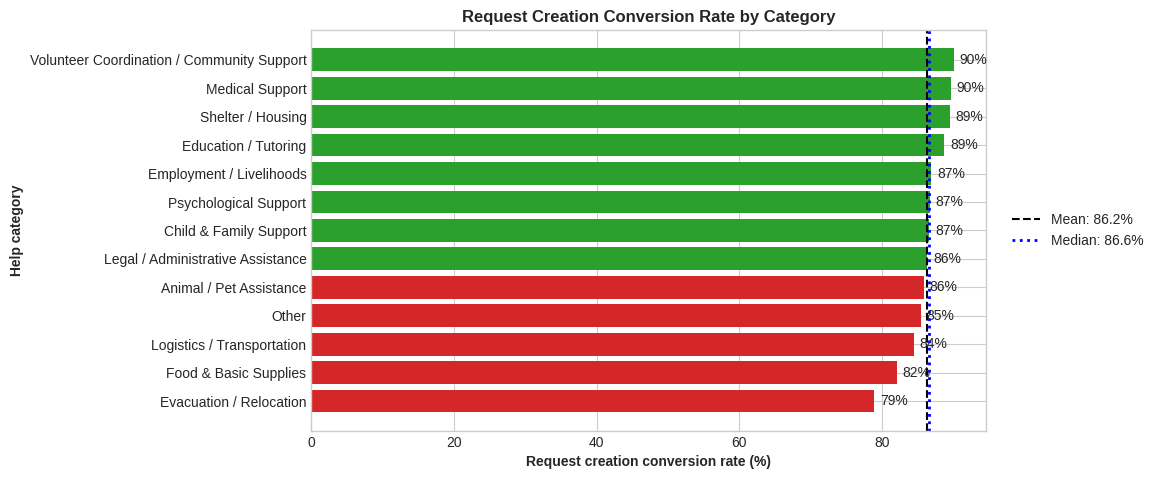

In [ ]:
# Sort just in case (descending)
df_plot = df.sort_values(
    by="requests_creation_conversion_rate",
    ascending=False
)

# Data for plotting
categories = df_plot["category"]
conversion_rates = df_plot["requests_creation_conversion_rate"] * 100  # to %

# Mean & median
mean_conversion = conversion_rates.mean()
median_conversion = conversion_rates.median()

# Colors relative to mean (higher = better)
colors = [
    "#2ca02c" if value >= mean_conversion else "#d62728"
    for value in conversion_rates
]

# Plot
fig, ax = plt.subplots(figsize=(10, max(4, 0.4 * len(categories))))

ax.barh(categories, conversion_rates, color=colors)
ax.invert_yaxis()  # highest conversion on top

# Mean line
ax.axvline(
    mean_conversion,
    linestyle="--",
    linewidth=1.5,
    color="black",
    label=f"Mean: {mean_conversion:.1f}%"
)

# Median line
ax.axvline(
    median_conversion,
    linestyle=":",
    linewidth=2,
    color="blue",
    label=f"Median: {median_conversion:.1f}%"
)

# Labels & title
ax.set_xlabel("Request creation conversion rate (%)", fontweight="bold")
ax.set_ylabel("Help category", fontweight="bold")
ax.set_title("Request Creation Conversion Rate by Category", fontweight="bold")

# Annotate bars
for i, value in enumerate(conversion_rates):
    ax.text(
        value + 0.8,
        i,
        f"{value:.0f}%",
        va="center"
    )

# Legend outside on the right
ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)

plt.subplots_adjust(right=0.8)

The conversion from the beginning of the form filling to the request creation is generally high in all categories (79–90%), which is a sign that the request creation process is clear and accessible.  
The highest conversions are in Volunteer Coordination/Community Support (90%), Medical Support, and Shelter/Housing, meaning that users in these categories are most likely to successfully complete the request submission.  
The lowest rates are observed in Evacuation/Relocation and Food&Basic Supplies, which may indicate more complex forms, higher emotional tension, or unclear user expectations at the submission stage.  
Overall, there are no significant decreases in conversion, but it is the lower categories that are priority candidates for UX improvements and clarification of the instructions for creating a request.

### **2.2.4. Form Abandonment Rate by Category**

Share of attempts to create a help request that were aborted by users before the request was successfully created, by help category.

In [ ]:
request_events = events_df[events_df["kind"] == "request"]

form_started = (
    request_events[request_events["event_name"] == "request_form_started"]
    .groupby("category_id")
    .size()
    .reset_index(name="form_started")
)

request_created = (
    request_events[request_events["event_name"] == "request_created"]
    .groupby("category_id")
    .size()
    .reset_index(name="request_created")
)

df = form_started.merge(
    request_created, on="category_id", how="left"
).fillna(0)

df["form_abandonment_rate"] = (
    1 - df["request_created"] / df["form_started"]
)

df = df.merge(
    help_categories_df, left_on="category_id", right_on="id", how="left"
)

# Sort by conversion rate (descending)
df = df.sort_values(
    by="form_abandonment_rate",
    ascending=False)


df[["category", "form_started", "request_created", "form_abandonment_rate"]]

,category,form_started,request_created,form_abandonment_rate
0,Evacuation / Relocation,123,97,0.211382
3,Food & Basic Supplies,145,119,0.179310
4,Logistics / Transportation,135,114,0.155556
12,Other,144,123,0.145833
11,Animal / Pet Assistance,141,121,0.141844
7,Legal / Administrative Assistance,139,120,0.136691
6,Child & Family Support,127,110,0.133858
5,Psychological Support,128,111,0.132812
8,Employment / Livelihoods,122,106,0.131148
9,Education / Tutoring,133,118,0.112782


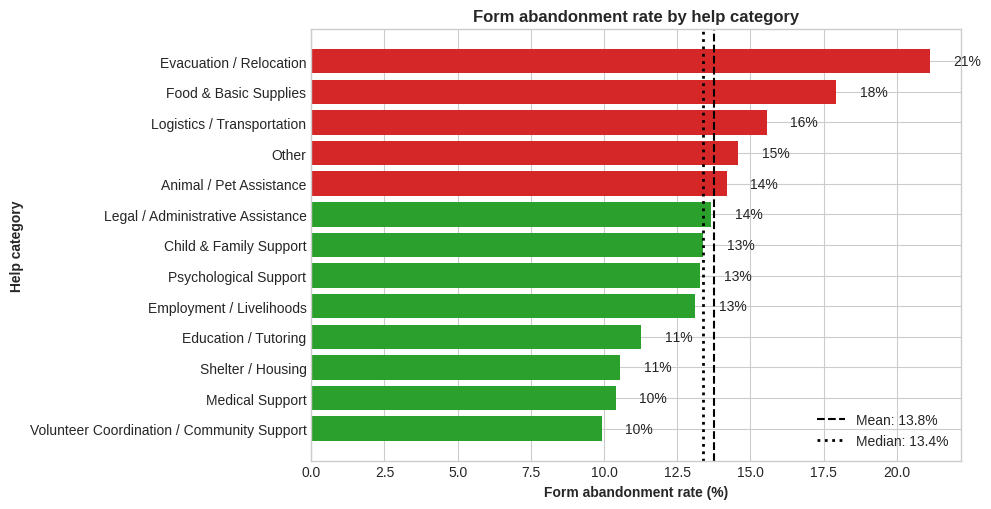

In [ ]:
# Sort just in case (descending)
df_plot = df.sort_values(
    by="form_abandonment_rate",
    ascending=False
)

# Data for plotting
categories = df_plot["category"]
conversion_rates = df_plot["form_abandonment_rate"] * 100  # to %

# Mean & median
mean_conversion = conversion_rates.mean()
median_conversion = conversion_rates.median()

# Colors relative to mean (lower = better)
colors = [
    "#d62728" if value >= mean_conversion else "#2ca02c"
    for value in conversion_rates
]

# Plot
fig, ax = plt.subplots(figsize=(10, max(4, 0.4 * len(categories))))

ax.barh(categories, conversion_rates, color=colors)
ax.invert_yaxis()

# Mean line
ax.axvline(
    mean_conversion,
    linestyle="--",
    linewidth=1.5,
    color="black",
    label=f"Mean: {mean_conversion:.1f}%"
)

# Median line
ax.axvline(
    median_conversion,
    linestyle=":",
    linewidth=2,
    color="black",
    label=f"Median: {median_conversion:.1f}%"
)

# Labels & title
ax.set_xlabel("Form abandonment rate (%)", fontweight="bold")
ax.set_ylabel("Help category", fontweight="bold")
ax.set_title("Form abandonment rate by help category", fontweight="bold")

# Annotate bars
for i, value in enumerate(conversion_rates):
    ax.text(
        value + 0.8,
        i,
        f"{value:.0f}%",
        va="center"
    )

# Legend
ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

The form abandonment rate varies significantly between categories, from 10% to 21%.  
The highest abandonment rates are observed in Evacuation/Relocation (21%) and Food & Basic Supplies (18%), which is explained by unclear requirements or expectations of users at the stage of filling out the form.  
The lowest rates are in Volunteer Coordination/Community Support (10%) and Medical Support (10%), where the user journey is the most understandable and “short”.  
Overall, most categories have an abandonment rate below 15%, which indicates a generally well-designed UX. At the same time, it is the categories with the highest dropouts that are prioritized for form optimization (simplification of fields, tips, examples).

## **2.3. Volunteer Activity KPIs**

### **2.3.1. Active Volunteers**

In [ ]:
# Сount the number of unique volunteers (helper(volunteer))
total_volunteers = users_df[
    users_df["role"].isin(["volunteer"])
].shape[0]

print(f"Total number of volunteers on the platform: {total_volunteers}")

Total number of volunteers on the platform: 159


Metric active_volunteers - the number of unique volunteers who successfully accepted at least one request for processing during the selected time period.

In [ ]:
start_date = "2025-08-01"
end_date_exclusive = "2026-02-02"

active_vol = (
    (events_df["event_name"] == "request_take_succeeded") &
    (events_df["kind"] == "request") &
    (events_df["user_role"] == "volunteer") &
    (events_df["occurred_at"] >= start_date) &
    (events_df["occurred_at"] < end_date_exclusive)
)

active_volunteers = events_df.loc[active_vol, "user_id"].nunique()
print(f'Unique volunteers with at least one accepted request: {active_volunteers}')

Unique volunteers with at least one accepted request: 155


Calculating the level of volunteer activity on the web platform.

In [ ]:
level_of_volunteer_activation = active_volunteers / total_volunteers
print(f'Volunteer Activity Level on the Platform: {level_of_volunteer_activation:.2f} %')

Volunteer Activity Level on the Platform: 0.97 %


Метрика active_volunteers показує, що за обраний період активно долучилися до веб-платформи та взяли щонайменше один запит у обробку 155 унікальних волонтерів. Отже, рівень активності волонтерів на веб-платформі становить приблизно 97%.

### **2.3.2. Request Acceptance Rate**

Metric requests_taken_rate - the proportion of created requests for help for which a volunteer successfully processed the request was recorded, for the selected time period.

In [ ]:
# Number of requests created
requests_created = events_df[
    (events_df["event_name"] == "request_created") &
    (events_df["kind"] == "request")
].shape[0]

# Number of requests processed by volunteers
requests_taken = events_df[
    (events_df["event_name"] == "request_take_succeeded") &
    (events_df["kind"] == "request")
].shape[0]

# Requests taken rate
requests_taken_rate = (
    requests_taken / requests_created
    if requests_created > 0 else 0
)

print(f'Number of requests created: {requests_created}')
print(f'Number of requests processed by volunteers: {requests_taken}')
print(f'Requests taken rate: {requests_taken_rate:.2%}')

Number of requests created: 1504
Number of requests processed by volunteers: 694
Requests taken rate: 46.14%


The requests_taken_rate metric shows that approximately 46% of created help requests were taken by volunteers. This means that almost every second help request is processed by volunteers, while the remaining requests remain unanswered or are waiting to be processed.

### **2.3.3. Volunteer load metrics**

A volunteer workload metric that shows how many requests a volunteer handles on average, how unevenly the work is distributed, and what proportion of volunteers take on a significant volume of requests.

In [ ]:
taken = events_df[
    (events_df["kind"] == "request") &
    (events_df["event_name"] == "request_take_succeeded") &
    (events_df["user_role"] == "volunteer")
]

# Number of unique requests for a volunteer
requests_per_volunteer = (
    taken.groupby("user_id")["help_id"]
    .nunique()
    .rename("requests_taken")
)

avg_requests_per_volunteer = requests_per_volunteer.mean()
p90_requests_per_volunteer = requests_per_volunteer.quantile(0.9)

pct_volunteers_1plus  = (requests_per_volunteer >= 1).mean()
pct_volunteers_5plus  = (requests_per_volunteer >= 5).mean()
pct_volunteers_10plus = (requests_per_volunteer >= 10).mean()

print(f"Avg requests per volunteer: {avg_requests_per_volunteer:.2f}")
print(f"P90 requests per volunteer: {p90_requests_per_volunteer:.0f}")
print(f"% volunteers with ≥1 request:  {pct_volunteers_1plus:.1%}")
print(f"% volunteers with ≥5 requests:  {pct_volunteers_5plus:.1%}")
print(f"% volunteers with ≥10 requests: {pct_volunteers_10plus:.1%}")

Avg requests per volunteer: 4.39
P90 requests per volunteer: 7
% volunteers with ≥1 request:  100.0%
% volunteers with ≥5 requests:  45.6%
% volunteers with ≥10 requests: 1.3%


Metrics show that the workload on volunteers is generally well balanced, including:
- all active volunteers take on at least one request;
- an average workload of around 4–5 requests per volunteer;
- only 1% of volunteers take on an excessively large volume (10+ requests).  

This means that the risk of system burnout is low and the web platform is not critically dependent on a narrow group of volunteers.

### **2.3.4. Volunteer Load by Category**

Metrics that show the workload on volunteers by category of assistance, in particular, how many unique requests a volunteer takes on average in each category, and how much the workload is “skewed”.

In [ ]:
# Volunteer load by category (based on "request_take_succeeded" events)

taken = events_df[
    (events_df["kind"] == "request") &
    (events_df["event_name"] == "request_take_succeeded") &
    (events_df["user_role"] == "volunteer")
].copy()

taken["category_id"] = pd.to_numeric(taken["category_id"], errors="coerce")
taken["user_id"] = pd.to_numeric(taken["user_id"], errors="coerce")
taken["help_id"] = pd.to_numeric(taken["help_id"], errors="coerce")

taken = taken.dropna(subset=["category_id", "user_id", "help_id"])
taken["category_id"] = taken["category_id"].astype(int)
taken["user_id"] = taken["user_id"].astype(int)
taken["help_id"] = taken["help_id"].astype(int)

# "volunteer - category" load (unique requests)
per_vol_cat = (
    taken.groupby(["category_id", "user_id"])["help_id"]
    .nunique()
    .reset_index(name="requests_taken")
)

# Aggregation by category
volunteer_load_by_category = (
    per_vol_cat.groupby("category_id", as_index=False)
    .agg(
        volunteers=("user_id", "nunique"),
        total_taken_requests=("requests_taken", "sum"),
        avg_requests_per_volunteer=("requests_taken", "mean"),
        p90_requests_per_volunteer=("requests_taken", lambda s: s.quantile(0.9)),
        pct_volunteers_1plus=("requests_taken", lambda s: (s >= 1).mean()),
        pct_volunteers_5plus=("requests_taken", lambda s: (s >= 5).mean()),
        pct_volunteers_10plus=("requests_taken", lambda s: (s >= 10).mean()),
    )
)

# Add category names
volunteer_load_by_category = volunteer_load_by_category.merge(
    help_categories_df[["id", "category"]],
    left_on="category_id",
    right_on="id",
    how="left"
)

# Final column category
volunteer_load_by_category["category"] = (
    volunteer_load_by_category["category"]
    .fillna(volunteer_load_by_category["category_id"].astype(str))
)

# Clean and sort
volunteer_load_by_category = (
    volunteer_load_by_category
    .drop(columns=["id"])
    .sort_values("avg_requests_per_volunteer", ascending=False)
)

# Output of the result
result = volunteer_load_by_category[[
    "category", "volunteers", "total_taken_requests",
    "avg_requests_per_volunteer", "p90_requests_per_volunteer",
    "pct_volunteers_1plus", "pct_volunteers_5plus", "pct_volunteers_10plus"
]].round({
    "avg_requests_per_volunteer": 2,
    "p90_requests_per_volunteer": 0,
    "pct_volunteers_1plus": 2,
    "pct_volunteers_5plus": 2,
    "pct_volunteers_10plus": 2,
})

result

,category,volunteers,total_taken_requests,avg_requests_per_volunteer,p90_requests_per_volunteer,pct_volunteers_1plus,pct_volunteers_5plus,pct_volunteers_10plus
2,Shelter / Housing,56,76,1.36,2.0,1.0,0.0,0.0
7,Legal / Administrative Assistance,42,57,1.36,2.0,1.0,0.0,0.0
3,Food & Basic Supplies,45,57,1.27,2.0,1.0,0.0,0.0
9,Education / Tutoring,45,55,1.22,2.0,1.0,0.0,0.0
6,Child & Family Support,41,50,1.22,2.0,1.0,0.0,0.0
10,Volunteer Coordination / Community Support,41,49,1.20,2.0,1.0,0.0,0.0
8,Employment / Livelihoods,39,46,1.18,2.0,1.0,0.0,0.0
5,Psychological Support,39,46,1.18,2.0,1.0,0.0,0.0
12,Other,50,58,1.16,2.0,1.0,0.0,0.0
11,Animal / Pet Assistance,49,54,1.10,1.0,1.0,0.0,0.0


This metric shows that the workload is evenly distributed across volunteers in each category.
On average, each volunteer takes about 1–2 requests, and the p90 does not exceed 1–2 requests per volunteer, indicating that there are no overloaded participants.
There are no volunteers in any category with a high intensity of participation (5+ or 10+ requests), meaning that there is no deep involvement of individual volunteers.
Overall, this indicates a broad but superficial engagement of the volunteer base, meaning that many volunteers participate, but mostly carry out only one request. This may be a sustainable model for scaling up and signals the need to develop mechanisms for re-engaging and retaining volunteers.

## **2.4. Help Effectiveness KPIs**

### **2.4.1. Request Completion Rate**

The proportion of requests for assistance that were successfully completed ('done') among requests that were processed by volunteers during the selected time period.

In [ ]:
# Requests for help processed
taken_requests = help_df[
    (help_df["kind"] == "request") &
    (help_df["status"].isin(["in_progress", "done"]))
]["id"].nunique()

# Help requests that have been completed
completed_requests = help_df[
    (help_df["kind"] == "request") &
    (help_df["status"] == "done")
]["id"].nunique()

completion_rate = (
    completed_requests / taken_requests
    if taken_requests > 0 else 0
)

print(f'Requests for help processed: {taken_requests}')
print(f'Help requests that have been completed: {completed_requests}')
print(f'Completion rate: {completion_rate:.2%}')

Requests for help processed: 627
Help requests that have been completed: 370
Completion rate: 59.01%


The completion_rate metric showed a fairly good result for the web platform, as about 59% of requests that were processed by volunteers were successfully completed. However, about 41% of requests remain incomplete (possible reasons: complexity of the request, lack of time, change of circumstances, etc.).

### **2.4.2. Avgerage Time to Complete Request**



The average time from the moment a volunteer successfully took the request into work (request_take_succeeded) to the moment it was completed (status = 'done' / completed_at) - only for completed requests.

In [ ]:
# Part of taking the request into work (first take) by help_id
taken_ts = (
    events_df[(events_df["kind"] == "request") & (events_df["event_name"] == "request_take_succeeded")]
    .groupby("help_id")["occurred_at"]
    .min()
    .rename("taken_at")
    .reset_index()
)

# Completed requests (take completed_at)
completed = help_df[
    (help_df["kind"] == "request") &
    (help_df["status"] == "done") &
    (help_df["completed_at"].notna())
][["id", "completed_at"]].rename(columns={"id": "help_id"})

# Combine and calculate the execution duration
df = completed.merge(taken_ts, on="help_id", how="inner")
df["time_to_complete_minutes"] = (df["completed_at"] - df["taken_at"]).dt.total_seconds() / 60

avg_minutes = df["time_to_complete_minutes"].mean()
median_minutes = df["time_to_complete_minutes"].median()

print(f"Completed requests: {len(df)}")
print(f"Avg time to complete: {avg_minutes:.1f} minutes ({avg_minutes/60:.2f} hours, {avg_minutes/1440:.2f} days)")
print(f"Median time to complete: {median_minutes:.1f} minutes ({median_minutes/60:.2f} hours, {median_minutes/1440:.2f} days)")

Completed requests: 370
Avg time to complete: 31414.8 minutes (523.58 hours, 21.82 days)
Median time to complete: 23608.4 minutes (393.47 hours, 16.39 days)


The metric shows that completed requests are processed on average approximately 22 days from the moment a volunteer takes them to process them. The median is lower (16 days), which means that there is a portion of requests that are processed much longer and “pull” the average up.

### **2.4.3. Average Time to Accept a Help Request**

The avg_time_to_take_request metric is the average time from the moment a request is created to the moment a volunteer successfully takes it into action.

In [ ]:
created = events_df[
    (events_df["kind"] == "request") &
    (events_df["event_name"] == "request_created")
]
taken = events_df[
    (events_df["kind"] == "request") &
    (events_df["event_name"] == "request_take_succeeded")
]

# Taking the first moment of creation/retrieval for each request (help_id)
created_ts = created.groupby("help_id")["occurred_at"].min().rename("created_at")
taken_ts = taken.groupby("help_id")["occurred_at"].min().rename("taken_at")

df = created_ts.to_frame().join(taken_ts, how="inner")
df["time_to_take_minutes"] = (df["taken_at"] - df["created_at"]).dt.total_seconds() / 60

avg_time_to_take_minutes = df["time_to_take_minutes"].mean()
avg_time_to_take_hours = avg_time_to_take_minutes / 60

print(f"Requests taken: {df.shape[0]}")
print(f"Avg time to take request: {avg_time_to_take_minutes:.1f} minutes ({avg_time_to_take_hours:.2f} hours)")

Requests taken: 694
Avg time to take request: 2069.1 minutes (34.49 hours)


The metric indicates that, on average, requests are accepted by volunteers within approximately 34.5 hours. This duration serves as an indicator of the platform’s responsiveness to newly created requests. Despite external challenges such as difficult operating conditions, shortages of supplies, or power outages, volunteer engagement remains relatively prompt.

### **2.4.4. Median Time to Completion by Category**

The metric is calculated only for completed requests and shows how long it typically takes to complete assistance in each category.

In [ ]:
# Completed requests only
df = help_df[
    (help_df["kind"] == "request") &
    (help_df["status"] == "done") &
    (help_df["completed_at"].notna())
].copy()

# Duration in days
df["days_to_completion"] = (
    (df["completed_at"] - df["created_at"])
    .dt.total_seconds() / (3600 * 24)
)

# Remove invalid values
df = df[(df["days_to_completion"] >= 0) & (df["days_to_completion"] <= 365)]

# Add category names
df = df.merge(
    help_categories_df,
    left_on="category_id",
    right_on="id",
    how="left"
)

df["category_label"] = df["category"].fillna(df["category_id"].astype(str))

# Median time by category
median_by_category = (
    df.groupby("category_label")["days_to_completion"]
    .median()
    .sort_values()
)

median_days_rounded = median_by_category.round(0).astype(int)

for category, days in median_days_rounded.items():
    print(f"{category}: {days} days")

Medical Support: 9 days
Food & Basic Supplies: 11 days
Logistics / Transportation: 12 days
Other: 13 days
Shelter / Housing: 15 days
Volunteer Coordination / Community Support: 17 days
Animal / Pet Assistance: 17 days
Psychological Support: 18 days
Employment / Livelihoods: 18 days
Education / Tutoring: 19 days
Evacuation / Relocation: 22 days
Legal / Administrative Assistance: 23 days
Child & Family Support: 29 days


In [ ]:
category_metrics = (
    df
    .groupby("category_label")
    .agg(
        requests_completed=("days_to_completion", "count"),
        mean_days=("days_to_completion", "mean"),
        median_days=("days_to_completion", "median"),
        p75_days=("days_to_completion", lambda x: x.quantile(0.75)),
        p90_days=("days_to_completion", lambda x: x.quantile(0.90)),
    )
    .sort_values("median_days", ascending=False)
)

category_metrics = category_metrics.round(1)
category_metrics

,requests_completed,mean_days,median_days,p75_days,p90_days
category_label,,,,,
Child & Family Support,28,28.3,28.7,35.3,52.2
Legal / Administrative Assistance,35,29.9,23.5,47.2,71.4
Evacuation / Relocation,21,31.2,21.8,44.1,73.0
Education / Tutoring,27,23.1,19.4,33.7,46.6
Employment / Livelihoods,19,18.4,18.3,26.9,41.9
Psychological Support,29,23.9,17.5,34.9,52.6
Animal / Pet Assistance,27,24.6,17.1,38.5,52.3
Volunteer Coordination / Community Support,26,22.2,17.1,28.8,49.3
Shelter / Housing,35,21.5,15.0,29.7,46.3


Request processing times vary significantly by category. Medical/Support and Logistics/Transportation are the fastest (median 9–12 days), indicating more streamlined processes and clear demand.
Legal/Administrative Assistance, Child and Family Support, and Psychological Support remain the slowest. This is explained by high averages and a long “tail” (p90 to 75 days), indicating the complexity of the cases and the lack of specialized resources.
In general, categories that require more expertise take longer to close, even if they have a higher number of completed requests compared to others.

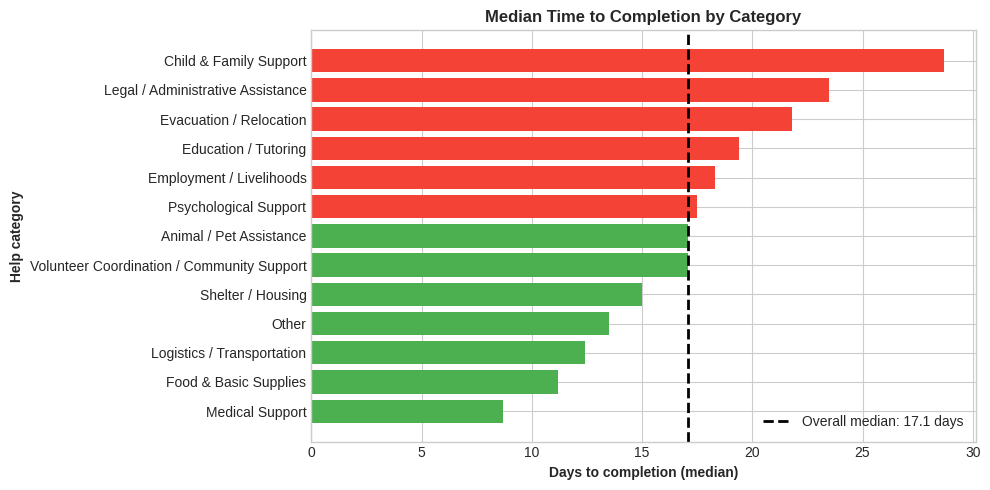

In [ ]:
# Benchmark: overall median by category
overall_median = category_metrics["median_days"].median()

# Colors relative to the line
colors = np.where(
    category_metrics["median_days"] <= overall_median,
    "#4CAF50",   # green — faster than benchmark
    "#F44336"    # red — slower than benchmark
)

plt.figure(figsize=(10, 5))

plt.barh(
    category_metrics.index,
    category_metrics["median_days"],
    color=colors
)

# Vertical benchmark line
plt.axvline(
    overall_median,
    linestyle="--",
    linewidth=2,
    color="black",
    label=f"Overall median: {overall_median:.1f} days"
)

plt.gca().invert_yaxis()
plt.title("Median Time to Completion by Category", fontweight="bold")
plt.xlabel("Days to completion (median)", fontweight="bold")
plt.ylabel("Help category", fontweight="bold")

plt.legend()
plt.tight_layout()
plt.show()

Median response times for assistance requests vary significantly across categories.
Medical Support, Food & Basic Supplies, and Logistics/Transportation are the fastest to close (below the overall median of 16 days).
The slowest responses are for assistance requests in the categories Child & Family Support and Legal/Administrative Assistance, which are significantly longer than the overall median, indicating more complex cases and the need for specialized resources.
Overall, operational assistance is completed faster, while social, legal, and family requests take longer.

## **2.5. Problem Detection Metrics**

### **2.5.1. Unhandled Requests Rate**

This is the proportion of requests that were not taken on by volunteers.

In [ ]:
created_requests = events_df[
    (events_df["kind"] == "request") &
    (events_df["event_name"] == "request_created")
]["help_id"].nunique()

taken_requests = events_df[
    (events_df["kind"] == "request") &
    (events_df["event_name"] == "request_take_succeeded")
]["help_id"].nunique()

unhandled_requests_rate = 1 - (taken_requests / created_requests) if created_requests > 0 else 0

# Only unique
print(f"Requests created: {created_requests}")
print(f"Taken into processing: {taken_requests}")
print(f"Share of unhandled requests: {unhandled_requests_rate:.2%}")

Requests created: 1504
Taken into processing: 694
Share of unhandled requests: 53.86%


The metric shows that approximately 54% of created requests for help were not processed by volunteers. This signals a “gap” between demand and the ability of the web platform to ensure timely processing of requests. The reason for this may be a shortage of volunteers, uneven categories/locations, complexity of requests, or problems with search/matching. It is necessary to attract more new volunteers and encourage existing volunteers to provide assistance.

### **2.5.2. Unanswered requests 48h**

The number of help requests that have been in the new status for more than 48 hours since creation.

In [ ]:
from datetime import timedelta

# Fixed "current" time for analysis
now = help_df["created_at"].max()

unanswered_requests_48h = help_df[
    (help_df["kind"] == "request") &
    (help_df["status"] == "new") &
    (now - help_df["created_at"] > timedelta(hours=48))
]

count_unanswered_requests_48h = unanswered_requests_48h["id"].nunique()

print(f"Requests in 'new' status for more than 48h: {count_unanswered_requests_48h}")

Requests in 'new' status for more than 48h: 857


The unanswered_requests_48h metric shows that 857 requests remain in the new status for more than 48 hours without a response from volunteers.   
This signals a critical backlog of requests that need attention and may indicate:
 - a shortage of volunteers;
 - an uneven distribution of requests across categories or locations;
 - a need for operational or product intervention (e.g., prioritization).

# **3. Exploratory Visualization**

## **3.1. Overall platform activity**

### **3.1.1. Total number of users on the web platform "Wings of Help**

In [ ]:
plt.style.use("seaborn-v0_8-whitegrid")

# Total unique users by role
counts = (
    users_df.groupby('role')['id']
    .nunique()
    .sort_values(ascending=False)
    )
print("Total users by role:")
print(counts)

Total users by role:
role
distressed    340
volunteer     159
admin           1
Name: id, dtype: int64


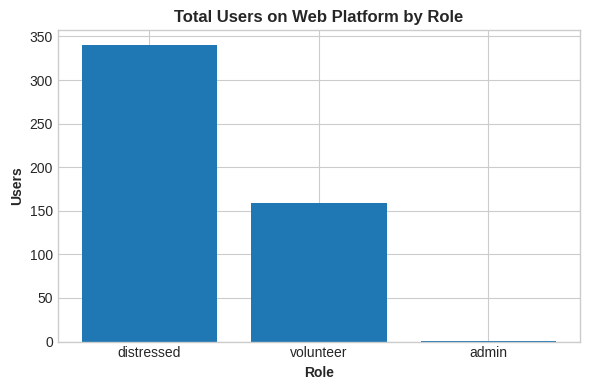

In [ ]:
# Plot
plt.figure(figsize=(6, 4))
plt.bar(counts.index.astype(str), counts.values)
plt.title("Total Users on Web Platform by Role", fontweight="bold")
plt.xlabel("Role", fontweight="bold")
plt.ylabel("Users", fontweight="bold")
plt.tight_layout()
plt.show()

From the graph, it is clear that the majority of platform users are Requesters (distressed) who need help, and Helpers (volunteers) are almost half as many. The administrator's role is minimal, which emphasizes the social focus of the "Winds of Help" web platform and the need to expand the volunteer community.

### **3.1.2. Percentage distribution of users and volunteers**

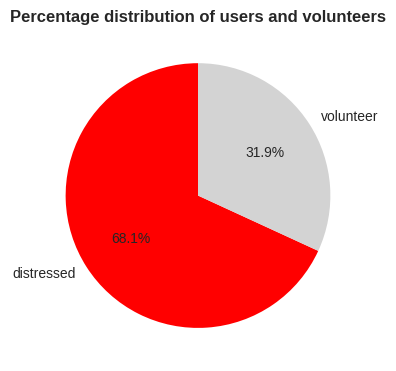

In [ ]:
# Exclude admins
users_no_admin = users_df[users_df["role"] != "admin"]

# Count users by role
role_counts = (
    users_no_admin.groupby("role")["id"]
    .nunique()
)

colors = ['red', 'lightgray']

# Plot pie chart
plt.figure(figsize=(4, 4))
plt.pie(
    role_counts.values,
    labels=role_counts.index,
    colors=colors,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Percentage distribution of users and volunteers", fontweight="bold")
plt.tight_layout()
plt.show()

The majority of users are Requesters (distressed) who need help (≈68%), while Helpers (volunteers) make up only ≈32%. This therefore indicates that demand outweighs supply and that there is a need to increase the number of volunteers to process requests for help more quickly.

### **3.1.3. Number of users who were active at least once**

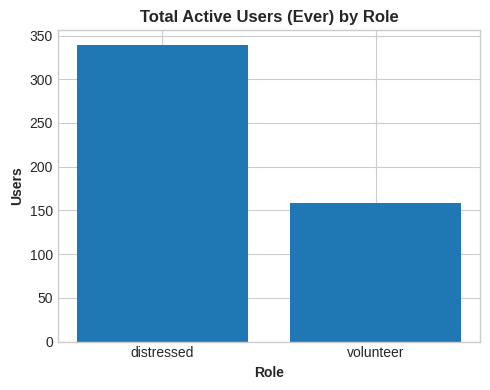

In [ ]:
counts = (
    events_df.groupby("user_role")["user_id"]
    .nunique()
    .sort_values(ascending=False)
)

plt.figure(figsize=(5, 4))
plt.bar(counts.index.astype(str), counts.values)
plt.title("Total Active Users (Ever) by Role", fontweight="bold")
plt.xlabel("Role", fontweight="bold")
plt.ylabel("Users", fontweight="bold")
plt.tight_layout()
plt.show()

### **3.1.4. Cumulative user base growth by role**

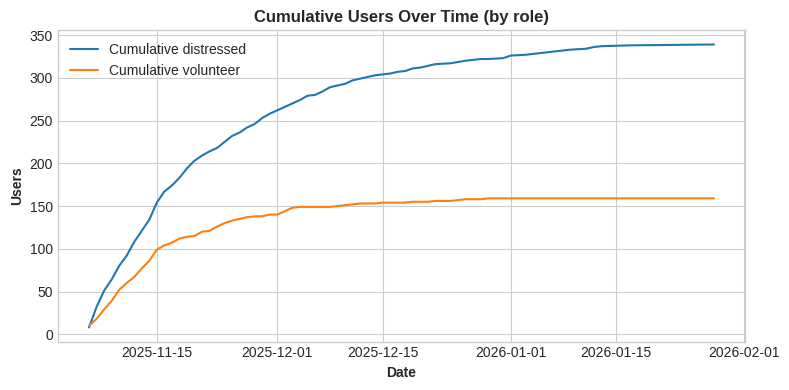

In [ ]:
events_df["dt"] = pd.to_datetime(events_df["occurred_at"], utc=True).dt.floor("D")

# first activity date per user within each role
first_seen = (
    events_df.groupby(["user_role", "user_id"])["dt"]
    .min()
    .reset_index()
)

# new users per day (by role)
new_per_day = (
    first_seen.groupby(["dt", "user_role"])["user_id"]
    .nunique()
    .unstack("user_role")
    .fillna(0)
    .sort_index()
)

# cumulative users over time
cum = new_per_day.cumsum()

plt.figure(figsize=(8, 4))
for col in cum.columns:
    plt.plot(cum.index, cum[col], label=f"Cumulative {col}")

plt.title("Cumulative Users Over Time (by role)", fontweight="bold")
plt.xlabel("Date", fontweight="bold")
plt.ylabel("Users", fontweight="bold")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

The graph shows the accumulation of users over time separately for Requeters (distressed) and for Helpers (volunteer).
The distressed line grows rapidly and almost without stopping, which is a sign that users in need of help are constantly being added throughout the period.
The volunteer line also grows at the beginning, but becomes monotonous quite early, meaning that the influx of new volunteers slows down significantly.
As a result, the gap between these two groups increases, meaning that the number of users in need of help is growing faster than those who are willing to provide it. This means that without additional volunteers, the load on existing volunteers will increase, and some requests may remain unanswered.

### **3.1.5. Number of events/help requests over time**

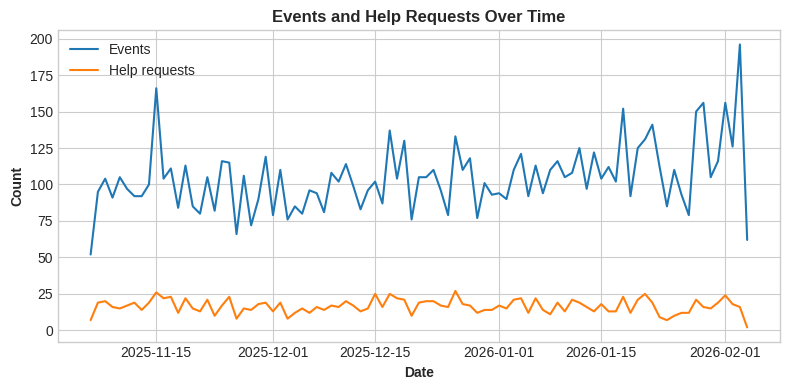

In [ ]:
plt.style.use("seaborn-v0_8-whitegrid")


# Parse datetime
events_df["occurred_at"] = pd.to_datetime(events_df["occurred_at"], utc=True)
help_df["created_at"] = pd.to_datetime(help_df["created_at"], utc=True)

# Choose granularity: "D" (daily) or "W" (weekly)
freq = "D"  # change to "W" for weekly

# Events over time
events_ts = (
    events_df.set_index("occurred_at")
          .resample(freq)
          .size()
          .rename("events_count")
)

# Help requests over time (only kind == 'request')
requests_ts = (
    help_df[help_df["kind"] == "request"]
        .set_index("created_at")
        .resample(freq)
        .size()
        .rename("requests_count")
)

# Combine into one table
ts = pd.concat([events_ts, requests_ts], axis=1).fillna(0)

# Plot
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(ts.index, ts["events_count"], label="Events")
ax.plot(ts.index, ts["requests_count"], label="Help requests")

ax.set_title("Events and Help Requests Over Time", fontweight="bold")
ax.set_xlabel("Date", fontweight="bold")
ax.set_ylabel("Count", fontweight="bold")

ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

The number of incidents gradually increases and fluctuates over time, while the number of calls for help remains relatively stable, without sharp peaks. This indicates a constant need for help.

### **3.1.6. Dynamics of user activity and help requests (7-day moving average)**

To smooth out daily fluctuations and identify major trends in user activity and help requests, we will apply a 7-day moving average.

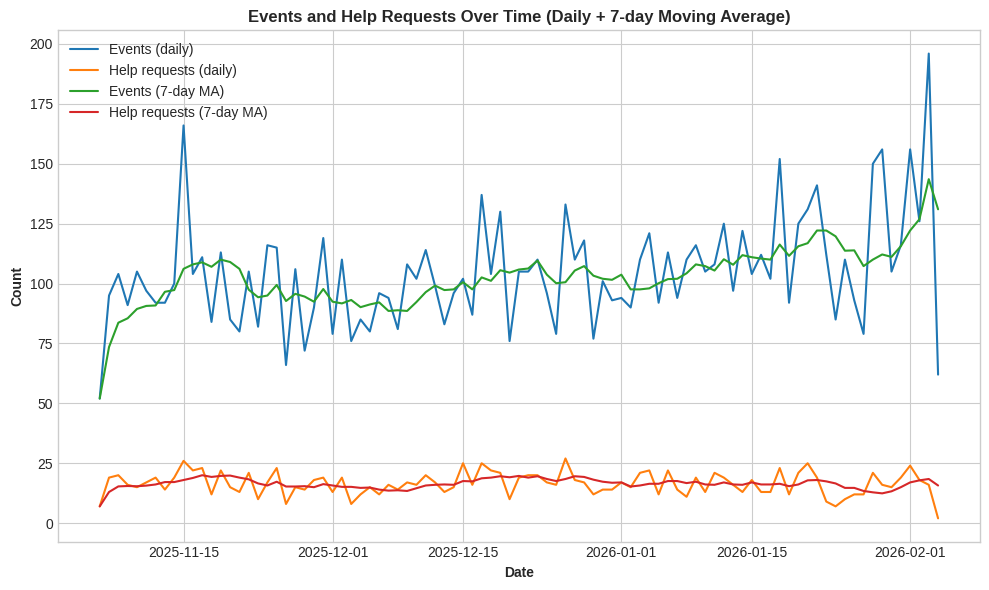

In [ ]:
plt.style.use("seaborn-v0_8-whitegrid")

# Parse datetime columns
events_df["occurred_at"] = pd.to_datetime(events_df["occurred_at"], utc=True)
help_df["created_at"] = pd.to_datetime(help_df["created_at"], utc=True)

# Aggregate to daily counts
events_daily = (
    events_df.set_index("occurred_at")
          .resample("D")
          .size()
          .rename("events_count")
)

requests_daily = (
    help_df[help_df["kind"] == "request"]
        .set_index("created_at")
        .resample("D")
        .size()
        .rename("requests_count")
)

# Align series into one dataframe (same calendar dates)
ts = pd.concat([events_daily, requests_daily], axis=1).fillna(0)

# Add 7-day moving average
ts["events_ma7"] = ts["events_count"].rolling(window=7, min_periods=1).mean()
ts["requests_ma7"] = ts["requests_count"].rolling(window=7, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(10, 6))

# Raw daily counts
ax.plot(ts.index, ts["events_count"], label="Events (daily)")
ax.plot(ts.index, ts["requests_count"], label="Help requests (daily)")

# 7-day moving average
ax.plot(ts.index, ts["events_ma7"], label="Events (7-day MA)")
ax.plot(ts.index, ts["requests_ma7"], label="Help requests (7-day MA)")

ax.set_title("Events and Help Requests Over Time (Daily + 7-day Moving Average)", fontweight="bold")
ax.set_xlabel("Date", fontweight="bold")
ax.set_ylabel("Count", fontweight="bold")

ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

The number of events is gradually increasing, meaning there is an increase in activity (initiatives, interactions, messages, etc.) on the site over time.  
The number of requests for help is almost non-existent and fluctuates within the same level, without a long-term upward or downward trend.  
This indicates that the increase in activity is not accompanied by a corresponding increase in the need for help.

### **3.1.7. Analysis of Daily Active Users by Role (Requesters vs. Helpers)**

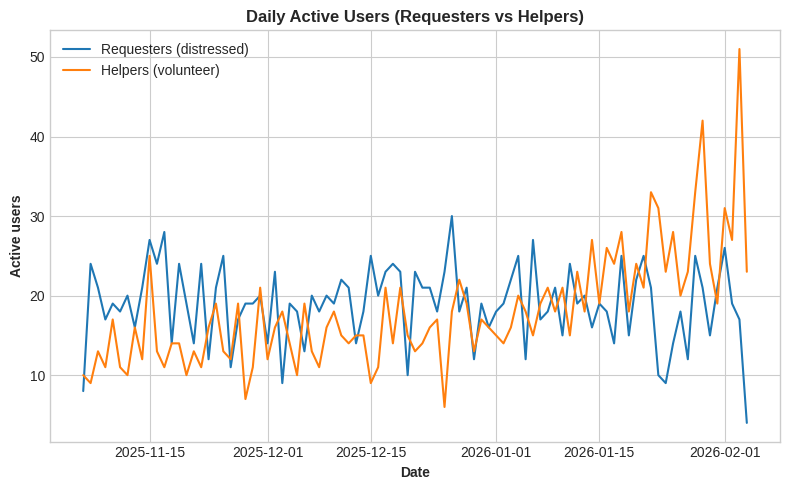

In [ ]:
# time column in this dataset is `occurred_at`
events_df["dt"] = pd.to_datetime(events_df["occurred_at"], utc=True).dt.floor("D")

# Overall activity
daily = (
    events_df.groupby(["dt", "user_role"])["user_id"]
    .nunique()
    .unstack("user_role")
    .fillna(0)
    .sort_index()
)

# Make sure both columns exist even if one role is missing in some date ranges
daily = daily.rename(columns={"distressed": "active_requesters", "volunteer": "active_helpers"})
for col in ["active_requesters", "active_helpers"]:
    if col not in daily.columns:
        daily[col] = 0

plt.figure(figsize=(8, 5))
plt.plot(daily.index, daily["active_requesters"], label="Requesters (distressed)")
plt.plot(daily.index, daily["active_helpers"], label="Helpers (volunteer)")
plt.title("Daily Active Users (Requesters vs Helpers)", fontweight="bold")
plt.xlabel("Date", fontweight="bold")
plt.ylabel("Active users", fontweight="bold")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

The activity of volunteers (helpers) increases noticeably over time and at the end of the period exceeds the activity of requesters, however, the number of people in need of help remains relatively stable with fluctuations. This indicates an increase in volunteer involvement and a gradual leveling of the imbalance between the demand and supply of help.

### **3.1.8. Completed Help Requests by Volunteers**

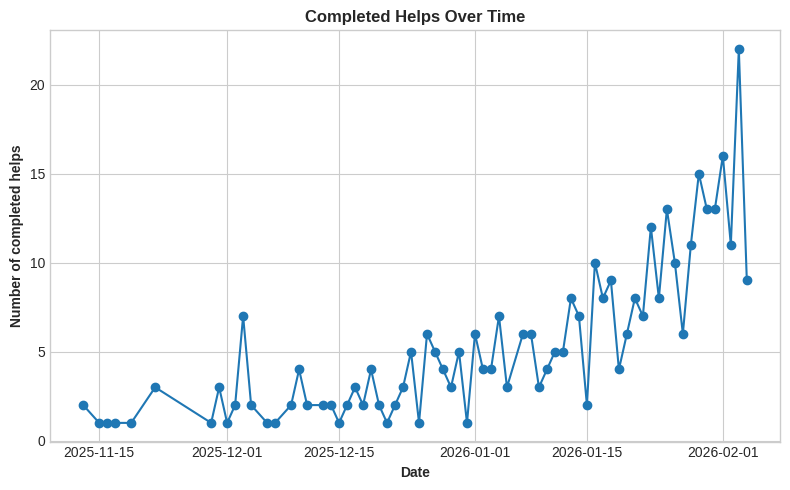

In [ ]:
# Parse date
events_df["dt"] = pd.to_datetime(events_df["occurred_at"], utc=True).dt.floor("D")

# Filter completed help events
completed = events_df[events_df["event_name"] == "request_completed"]

# Count completed helps per day
daily_completed = (
    completed.groupby("dt")
    .size()
    .reset_index(name="completed_helps")
)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(
    daily_completed["dt"],
    daily_completed["completed_helps"],
    marker="o"
)

plt.title("Completed Helps Over Time", fontweight="bold")
plt.xlabel("Date", fontweight="bold")
plt.ylabel("Number of completed helps", fontweight="bold")
plt.grid(True)
plt.tight_layout()
plt.show()

It is clear from the graph that the number of successfully completed requests for help increases over time, especially towards the end of the period, which indicates increased efficiency of the web platform and better interaction between users in need of help and volunteers providing assistance.

### **3.1.9. Help Requests Successfully Taken by Volunteers**

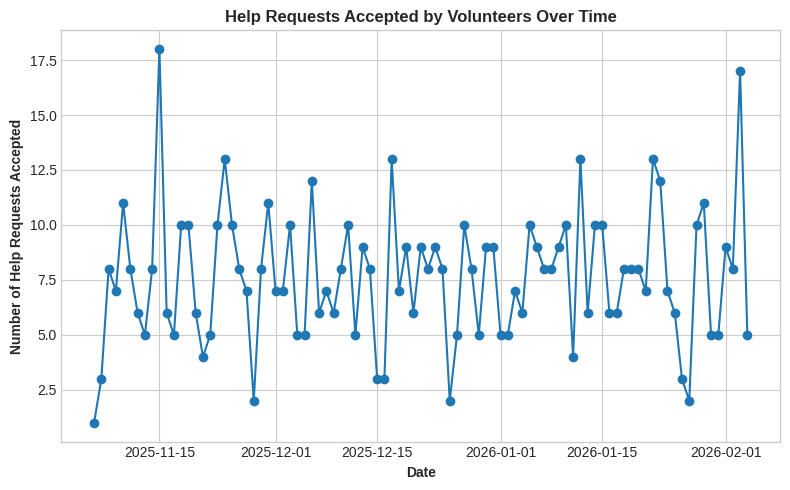

In [ ]:
taken = events_df[events_df["event_name"] == "request_take_succeeded"]

daily_taken = (
    taken.groupby("dt")
    .size()
    .reset_index(name="helps_taken")
)

plt.figure(figsize=(8, 5))
plt.plot(
    daily_taken["dt"],
    daily_taken["helps_taken"],
    marker="o"
)

plt.title("Help Requests Accepted by Volunteers Over Time", fontweight="bold")
plt.xlabel("Date", fontweight="bold")
plt.ylabel("Number of Help Requests Accepted", fontweight="bold")
plt.grid(True)
plt.tight_layout()
plt.show()

The graph shows the fluctuations in the number of requests for help accepted by volunteers. The line is held at a stable level, indicating constant volunteer involvement without a pronounced long-term increase.

### **3.1.10. Distribution of Records by Status (Absolute Values)**

Column (bar) chart shows absolute values, i.e. the number of records on the web platform. It also allows you to clearly count and compare the number of records in each status.

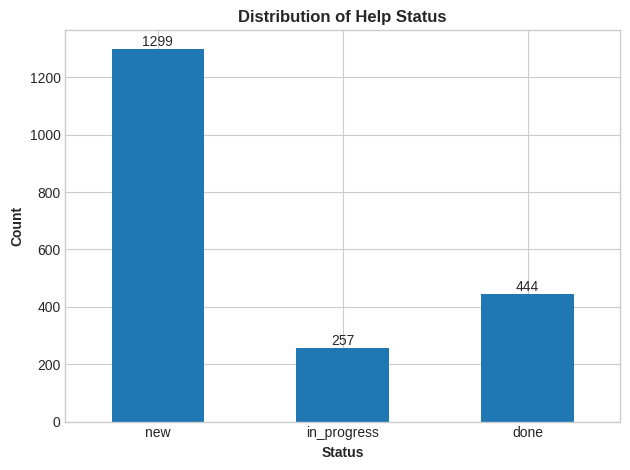

In [ ]:
# Counting statuses in the correct order
status_order = ['new', 'in_progress', 'done']
status_counts = help_df['status'].value_counts().reindex(status_order)

# Graph construction
plt.figure()
ax = status_counts.plot(kind='bar')
plt.xticks(rotation=0)

# Adding column labels
for i, value in enumerate(status_counts):
    if pd.notna(value):
        ax.text(i, value, str(int(value)),
                ha='center',
                va='bottom')

plt.xlabel('Status', fontweight="bold")
plt.ylabel('Count', fontweight="bold")
plt.title('Distribution of Help Status', fontweight="bold")

plt.tight_layout()
plt.show()

The majority of help requests on the web platform have a status of “new” (1299), which significantly exceeds the number of completed (444) and ongoing (257). This indicates a high need for help, a load or backlog of new tasks, and a potential need to speed up their processing.

### **3.1.11. Distribution of Records by Status (Relative Share, %)**

Using a Pie chart, we will display the percentage of each status from the total.

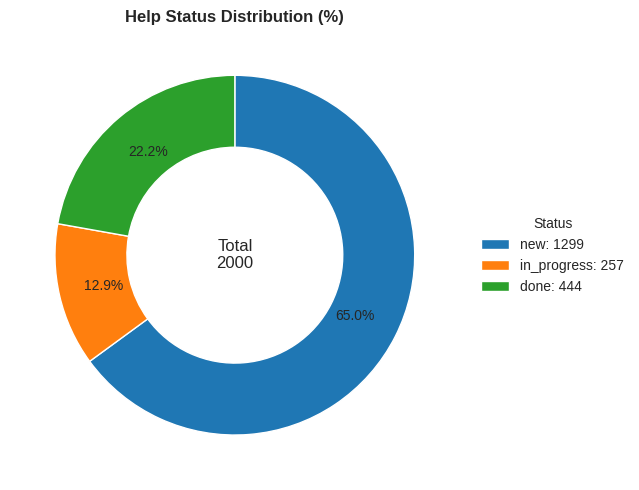

In [ ]:
# Data preparation
status_order = ['new', 'in_progress', 'done']
status_counts = (
    help_df['status']
    .value_counts()
    .reindex(status_order)
    .fillna(0)
    .astype(int)
)

# Removing zero categories
status_counts = status_counts[status_counts > 0]

total = int(status_counts.sum())

# Create donut chart
fig, ax = plt.subplots(figsize=(7, 5))

wedges, texts, autotexts = ax.pie(
    status_counts.values,
    labels=None,                 # Entering names in the legend
    autopct='%1.1f%%',
    startangle=90,
    counterclock=False,
    pctdistance=0.75,
    wedgeprops=dict(width=0.40, edgecolor='white', linewidth=1)
)

# Center (Total)
ax.text(0, 0, f"Total\n{total}", ha="center", va="center", fontsize=12)

# Legend
legend_labels = [f"{k}: {v}" for k, v in status_counts.items()]
ax.legend(
    wedges, legend_labels,
    title="Status",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

plt.setp(autotexts, fontsize=10)
ax.set_title("Help Status Distribution (%)", fontweight="bold")
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

The majority of records are in the “new” status (65%), indicating a significant volume of applications that have not yet been processed. Completed accounts for 22.2%, and in progress for 12.9%, which may indicate a need to optimize the speed of application processing.

## **3.2. User Behavioral Analysis**

### **3.2.1. User distribution by actual behavior**



behavior_type
Only receive help       339
Both: receive & help    146
Only help                13
Name: count, dtype: int64


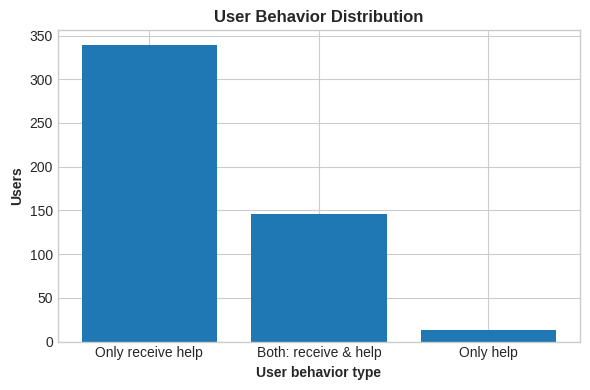

In [ ]:
# Define behavior events
request_events = {
    "request_form_submitted",
    "request_created",
    "request_completed"
}

helper_events = {
    "offer_created",
    "request_take_succeeded",
    "offer_matched"
}

# Flags per user
user_behavior = (
    events_df.assign(
        is_requester=events_df["event_name"].isin(request_events),
        is_helper=events_df["event_name"].isin(helper_events),
    )
    .groupby("user_id")[["is_requester", "is_helper"]]
    .any()
    .reset_index()
)

# Classify users
def classify(row):
    if row.is_requester and row.is_helper:
        return "Both: receive & help"
    elif row.is_requester:
        return "Only receive help"
    elif row.is_helper:
        return "Only help"
    else:
        return "No core activity"

user_behavior["behavior_type"] = user_behavior.apply(classify, axis=1)

# Count users (exclude 'No core activity' if needed)
distribution = (
    user_behavior["behavior_type"]
    .value_counts()
    .drop("No core activity", errors="ignore")
)

print(distribution)

# Plot
plt.figure(figsize=(6, 4))
plt.bar(distribution.index, distribution.values)
plt.title("User Behavior Distribution", fontweight="bold")
plt.xlabel("User behavior type", fontweight="bold")
plt.ylabel("Users", fontweight="bold")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The graph shows that the vast majority of users only receive help, a much smaller number of users combine receiving and giving help, and very few users only help. This indicates a small number of volunteers and limited mutual participation, as well as a need for users to transition into a more active role, such as volunteering.

### **3.2.2. Share of user distribution by actual behavior**

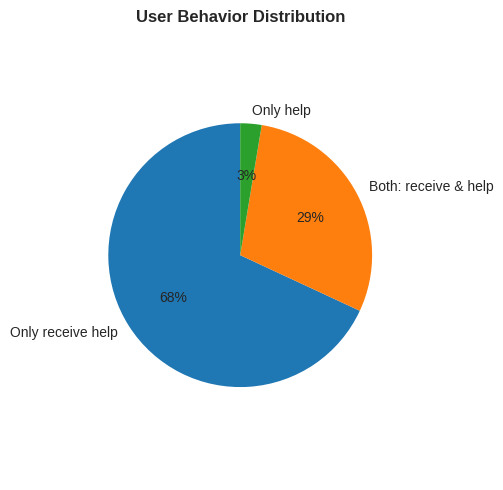

In [ ]:
plt.figure(figsize=(5, 5))
plt.pie(
    distribution.values,
    labels=distribution.index,
    autopct="%1.f%%",
    startangle=90
)
plt.title("User Behavior Distribution", fontweight="bold")
plt.axis("equal")
plt.tight_layout()
plt.show()

The diagram shows that the majority of users (≈68%) only receive help, almost a third (≈29%) not only receive help but also provide help, and only ≈3% act exclusively as volunteers. This indicates the dominance of the Requesters (distressed) role and the need to attract more volunteers to provide active help to others.

### **3.2.3. Histogram of Completed Help Requests per User**

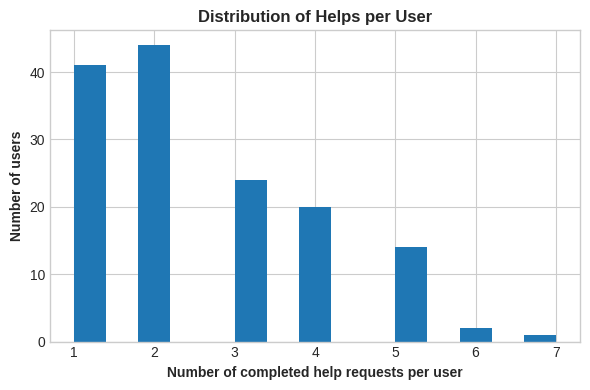

In [ ]:
# Select only request_completed
completed = events_df[events_df["event_name"] == "request_completed"]

# How many help requests each user has handled
helps_per_user = (
    completed.groupby("user_id")
    .size()
    .rename("helps_count")
)

plt.figure(figsize=(6, 4))
plt.hist(helps_per_user, bins=15)
plt.title("Distribution of Helps per User", fontweight="bold")
plt.xlabel("Number of completed help requests per user", fontweight="bold")
plt.ylabel("Number of users", fontweight="bold")
plt.tight_layout()
plt.show()

The majority of help requests are handled by a broad range of low-activity users, while a narrow group of very active volunteers handles a significantly higher number of help requests. This is a sign that there are a small number of key Helpers (volunteers) on the web platform, and they should be supported and motivated, while encouraging less active users to handle help requests more often.

### **3.2.4. Distribution of Completed Help Requests per User (boxplot)**

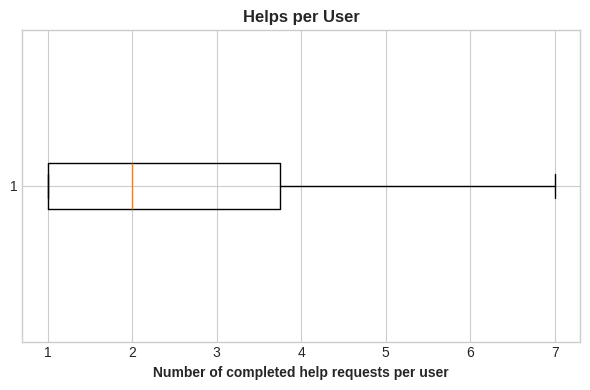

In [ ]:
plt.figure(figsize=(6, 4))
plt.boxplot(helps_per_user, vert=False)
plt.title("Helps per User", fontweight="bold")
plt.xlabel("Number of completed help requests per user", fontweight="bold")
plt.tight_layout()
plt.show()

The distribution of completed help requests per user is asymmetric. Thus, the platform relies heavily on a small number of active volunteers, with most users handling only 1–2 help requests. This, therefore, highlights the importance of retaining and supporting active users while at the same time providing incentives to encourage less active users to re-handle a request.

### **3.2.5. User registrations on the web platform by month**

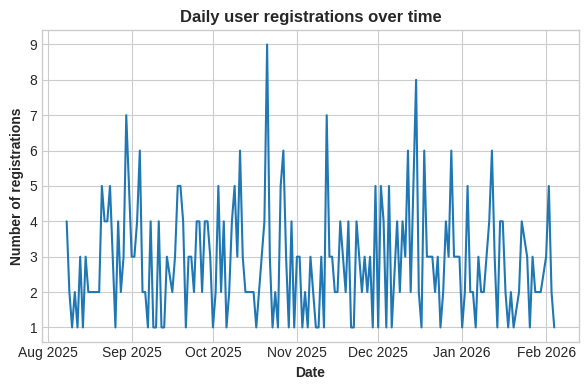

In [ ]:
# Convert date_joined to datetime
users_df["date_joined"] = pd.to_datetime(users_df["date_joined"])

# Grouping by day
daily_registrations = (
    users_df
    .groupby(users_df["date_joined"].dt.date)
    .size()
)

# Convert index back to datetime
daily_registrations.index = pd.to_datetime(daily_registrations.index)

# Creating a graph
plt.figure(figsize=(6, 4))
plt.plot(daily_registrations.index, daily_registrations.values)

plt.xlabel("Date", fontweight="bold")
plt.ylabel("Number of registrations", fontweight="bold")
plt.title("Daily user registrations over time", fontweight="bold")

# Format month
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

plt.tight_layout()
plt.show()

The graph shows the number of daily registrations without a clear upward or downward trend, indicating a steady but uneven influx of new users over the period from August 2025 to February 2026.

## **3.3. Analysis of requests and offers for help**

### **3.3.1. Graph of the number of requests and offers**

Two visualizations were used to analyze activity on the platform. A bar chart shows the absolute number of requests and offers for help, while a pie chart allows you to quickly assess their relative share.

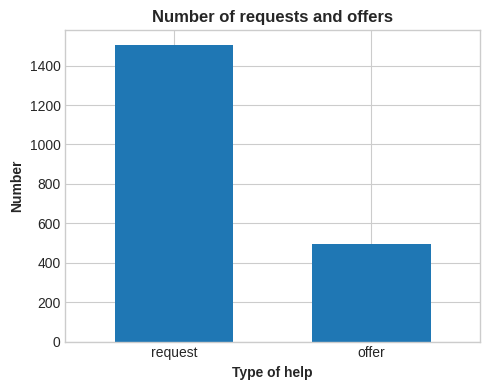

In [ ]:
# Style
plt.style.use("seaborn-v0_8-whitegrid")

# Counting the number of requests/offers
kind_counts = help_df['kind'].value_counts()


# Creating a graph
plt.figure(figsize=(5, 4))
ax = kind_counts.plot(kind='bar', width=0.6)

plt.xlabel('Type of help', fontweight='bold')
plt.ylabel('Number', fontweight='bold')
plt.title('Number of requests and offers', fontweight='bold')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

The resulting graph shows the ratio between the absolute number of requests for help and offers from volunteers and allows us to assess the balance of demand and offer on the platform. So, as can be seen from the graph, there are significantly more requests for help than offers, which indicates a greater need for support than a willingness to provide it.

### **3.3.2. Share of requests and offers to the web platform**

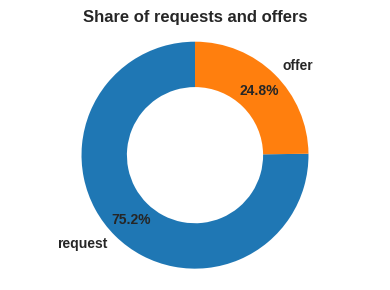

In [ ]:
# Count requests/offers
kind_counts = help_df["kind"].value_counts()
total = kind_counts.sum()

# Style
plt.style.use("seaborn-v0_8-whitegrid")


plt.figure(figsize=(4, 3))
plt.pie(
    kind_counts.values,
    labels=kind_counts.index,
    autopct="%1.1f%%",
    pctdistance=0.8,
    startangle=90,
    wedgeprops={"width": 0.4},  # donut hole
    textprops={'fontweight': 'bold'}
)

plt.title("Share of requests and offers", fontweight="bold")
plt.axis("equal")  # keep it circular
plt.tight_layout()
plt.show()

The graph shows that most of the appeals concern requests for help (≈75%), while offers of help occur much less frequently (≈25%). This indicates that there is a greater need for requests for help than a willingness to provide it.

### **3.3.3. Top 10 Volunteers by Processed Help Requests**

In [ ]:
# Filter completed helps by volunteers
completed_helpers = events_df[
    (events_df["event_name"] == "request_completed") &
    (events_df["user_role"] == "volunteer")
]

# Count completed helps per volunteer
helps_per_volunteer = (
    completed_helpers.groupby("user_id")
    .size()
    .rename("completed_helps")
    .sort_values(ascending=False)
)

# Choose Top N
N = 10
top_helpers = helps_per_volunteer.head(N).reset_index()

# Build full name
users_df['full_name'] = users_df['first_name'].fillna("")+ " " + users_df['last_name'].fillna("").str.strip()

# Join with users table
top_helpers = top_helpers.merge(
    users_df[['id', 'full_name']],
    left_on='user_id',
    right_on='id',
    how='left'
)

# Table show full names
print(top_helpers[["user_id", "full_name", "completed_helps"]])

   user_id         full_name  completed_helps
0      329  Vadim Bondarenko                7
1      140    Petro Klimenko                6
2      393   Andrii Petrenko                6
3       87   Anastasia Boyko                5
4      347     Daria Makarov                5
5      321        Glib Boyko                5
6      359  Oksana Tkachenko                5
7      192   Kateryna Melnyk                5
8      349  Iryna Ivanchenko                5
9      447      Iryna Melnyk                5


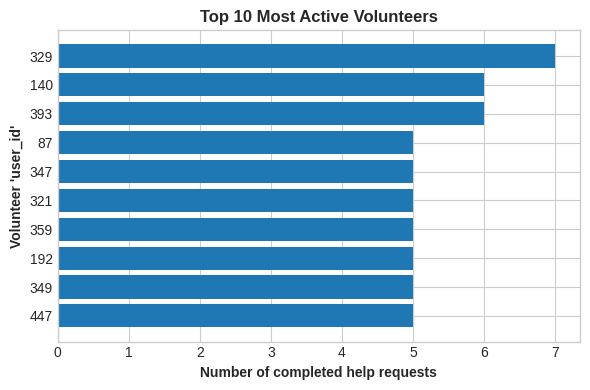

In [ ]:
# Creating a graph
plt.figure(figsize=(6, 4))
plt.barh(
    top_helpers["user_id"].astype(str),
    top_helpers["completed_helps"]
)

plt.gca().invert_yaxis()  # #1 зверху
plt.title(f"Top {N} Most Active Volunteers", fontweight="bold")
plt.xlabel("Number of completed help requests", fontweight="bold")
plt.ylabel("Volunteer 'user_id'", fontweight="bold")
plt.tight_layout()
plt.show()

The graph shows the highest activity of volunteers, who process 5–7 requests for assistance each. Therefore, the 10 users listed play a crucial role in ensuring a significant portion of the web platform's request processing for assistance.

### **3.3.4. Distribution of Request Resolution Time (Days)**

In [ ]:
# Copy of dataframe
df = help_df.copy()

# Convert to datetime
df['created_at'] = pd.to_datetime(df['created_at'])
df['completed_at'] = pd.to_datetime(df['completed_at'])

# Only completed applications
completed = df[df['completed_at'].notna()].copy()

# Time difference
completed['resolution_time_hours'] = (
    (completed['completed_at'] - completed['created_at'])
    .dt.total_seconds() / 3600
)

print(completed[['created_at', 'completed_at', 'resolution_time_hours']].head())

                         created_at                     completed_at  \
0  2025-11-28 15:41:51.497101+00:00 2026-01-09 22:08:27.497101+00:00   
10 2025-12-11 11:55:48.497101+00:00 2026-01-08 08:50:28.497101+00:00   
23 2025-11-28 13:52:21.497101+00:00 2026-01-22 00:28:44.497101+00:00   
28 2025-11-24 04:19:48.497101+00:00 2025-12-07 11:11:19.497101+00:00   
30 2026-01-23 13:07:25.497101+00:00 2026-01-29 20:42:46.497101+00:00   

    resolution_time_hours  
0             1014.443333  
10             668.911111  
23            1306.606389  
28             318.858611  
30             151.589167  


Histogram of Request Resolution Time.

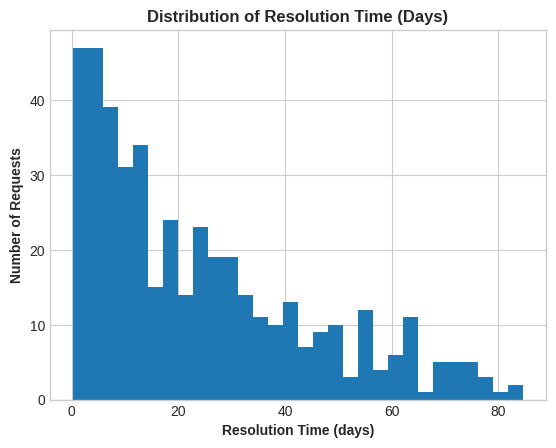

In [ ]:
completed['resolution_time_days'] = (
    (completed['completed_at'] - completed['created_at'])
    .dt.total_seconds() / 86400
)

plt.figure()

plt.hist(completed['resolution_time_days'], bins=30)

plt.xlabel('Resolution Time (days)', fontweight="bold")
plt.ylabel('Number of Requests', fontweight="bold")
plt.title('Distribution of Resolution Time (Days)', fontweight="bold")

plt.show()

The graph shows that the highest concentration is observed in the first 5–15 days. Most requests are resolved in a short time, mostly up to 20 days. The distribution has a right-sided asymmetry (long “tail”), which means that there are individual cases with a long resolution time (50–80 days).

So, overall, the resolution process is relatively fast for most requests, but there are isolated delays that may require additional analysis.

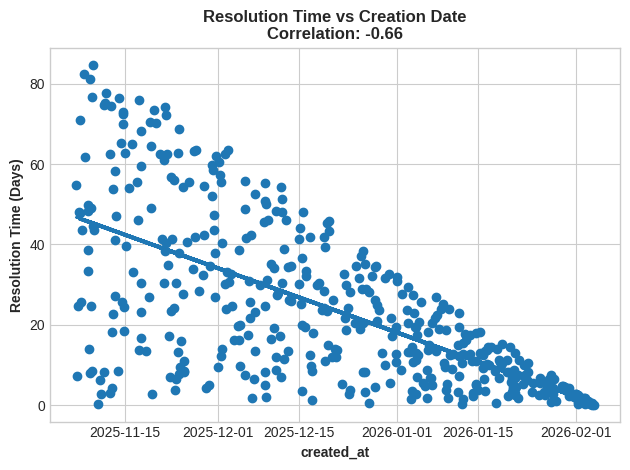

In [ ]:
# Перетворення дат
help_df['created_at'] = pd.to_datetime(help_df['created_at'])
help_df['completed_at'] = pd.to_datetime(help_df['completed_at'])

# Беремо тільки завершені заявки
completed = help_df[help_df['completed_at'].notna()].copy()

# Розрахунок часу виконання (в днях)
completed['resolution_time_days'] = (
    (completed['completed_at'] - completed['created_at'])
    .dt.total_seconds() / 86400
)

# Числове представлення дати для кореляції
completed['created_ordinal'] = completed['created_at'].map(pd.Timestamp.toordinal)

# Коефіцієнт кореляції
correlation = completed['created_ordinal'].corr(completed['resolution_time_days'])

# Лінія регресії
z = np.polyfit(
    completed['created_ordinal'],
    completed['resolution_time_days'],
    1
)
p = np.poly1d(z)

# Побудова графіка
plt.figure()

plt.scatter(
    completed['created_at'],
    completed['resolution_time_days']
)

# Лінія тренду
plt.plot(
    completed['created_at'],
    p(completed['created_ordinal'])
)

plt.xlabel('created_at', fontweight="bold")
plt.ylabel('Resolution Time (Days)', fontweight="bold")
plt.title(f'Resolution Time vs Creation Date\nCorrelation: {correlation:.2f}',  fontweight="bold")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The graph shows the relationship between the date the request was created (X) and the time it took to complete it in days (Y). Each point on the graph represents one completed request. It is also noticeable that at the beginning of the period there is a large spread (large dispersion), and at the end of the period the points are densely grouped - the process has become more stable.
The resulting correlation (–0.66) means that there is a significant negative correlation, i.e. the later the request was created, the faster it was closed.

The regression line shows the decrease in order completion time over time. As can be seen from the graph, at the beginning of the period orders were closed in 40–80 days, and at the end of the period most orders are closed in 1–15 days.


### **3.3.5. Pearson correlation test (p-value)**

This will test the hypothesis:
*   H0: There is no correlation (ρ = 0).
*   H1: There is a correlation (ρ ≠ 0).

In [ ]:
from scipy.stats import pearsonr, spearmanr

# Transform data
help_df['created_at'] = pd.to_datetime(help_df['created_at'])
help_df['completed_at'] = pd.to_datetime(help_df['completed_at'])

# Only accept completed_at
completed = help_df[help_df['completed_at'].notna()].copy()

# Calculation of execution time (in days)
completed['resolution_time_days'] = (
    (completed['completed_at'] - completed['created_at'])
    .dt.total_seconds() / 86400
)

# Numeric representation of the date
completed['created_ordinal'] = completed['created_at'].map(pd.Timestamp.toordinal)

# Pearson correlation test
corr_coef, p_value = pearsonr(
    completed['created_ordinal'],
    completed['resolution_time_days']
)
# Spearmanr correlation test
spearman_corr, spearman_p = spearmanr(
    completed['created_ordinal'],
    completed['resolution_time_days']
)

print(f"Correlation coefficient: {corr_coef:.4f}")
print(f"P-value: {p_value:.60f}")
print()
print(f"Spearman correlation: {spearman_corr:.4f}")
print(f"P-value: {spearman_p:.60f}")

Correlation coefficient: -0.6608
P-value: 0.000000000000000000000000000000000000000000000000000000004731

Spearman correlation: -0.6724
P-value: 0.000000000000000000000000000000000000000000000000000000000010


A moderate negative correlation between the variables was found (Pearson ≈ -0.66, Spearman ≈ -0.67), which is a sign that as one variable increases, the other tends to decrease. An extremely small p-value indicates statistical significance of the relationship, i.e. the result obtained is reliable and unlikely to be random.

### **3.3.6. Execution time vs number of requests per day**

Hypothesis: Does the daily workload (number of requests created) affect their execution time?

Pearson correlation: 0.0706
Pearson p-value: 0.1372615483756228
Spearman correlation: 0.033
Spearman p-value: 0.48843758185887387


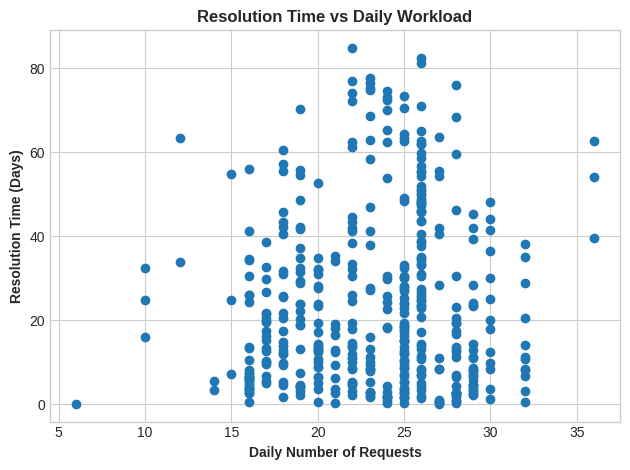

In [ ]:
from scipy.stats import pearsonr, spearmanr

# Transform data
help_df['created_at'] = pd.to_datetime(help_df['created_at'])
help_df['completed_at'] = pd.to_datetime(help_df['completed_at'])

# Oly accept completed_at
completed = help_df[help_df['completed_at'].notna()].copy()

# Calculation of execution time (in days)
completed['resolution_time_days'] = (
    (completed['completed_at'] - completed['created_at'])
    .dt.total_seconds() / 86400
)

# Calculating the load - the number of requests each day
help_df['created_date'] = help_df['created_at'].dt.date

daily_load = (
    help_df.groupby('created_date')
    .size()
    .reset_index(name='daily_requests')
)

# Add daily workload to completed applications
completed['created_date'] = completed['created_at'].dt.date

completed = completed.merge(
    daily_load,
    on='created_date',
    how='left'
)

# Correlation Pearson
pearson_corr, pearson_p = pearsonr(
    completed['daily_requests'],
    completed['resolution_time_days']
)

# Correlation Spearman
spearman_corr, spearman_p = spearmanr(
    completed['daily_requests'],
    completed['resolution_time_days']
)

print("Pearson correlation:", round(pearson_corr, 4))
print("Pearson p-value:", pearson_p)

print("Spearman correlation:", round(spearman_corr, 4))
print("Spearman p-value:", spearman_p)

# Scatter plot
plt.figure()

plt.scatter(
    completed['daily_requests'],
    completed['resolution_time_days']
)

plt.xlabel('Daily Number of Requests', fontweight="bold")
plt.ylabel('Resolution Time (Days)', fontweight="bold")
plt.title('Resolution Time vs Daily Workload', fontweight="bold")

plt.tight_layout()
plt.show()

Correlation analysis shows no statistically significant relationship between daily workload and request resolution time (Pearson r = 0.07, p > 0.05). This suggests that system performance remains stable regardless of daily request volume.

## **3.4. Categories of help**

### **3.4.1. Distribution of requests by category**

In [ ]:
# Number of unique requests created by category
requests_by_category = (
    events_df[
        (events_df["kind"] == "request") &
        (events_df["event_name"] == "request_created")
    ]
    .groupby("category_id")["help_id"]
    .nunique()
    .rename("requests_created")
    .reset_index()
)

# Adding category names
requests_by_category = requests_by_category.merge(
    help_categories_df,
    left_on="category_id",
    right_on="id",
    how="left"
)

requests_by_category["category"] = (
    requests_by_category["category"]
    .fillna(requests_by_category["category_id"].astype(str))
)

# Share of total
total_requests = requests_by_category["requests_created"].sum()
requests_by_category["share"] = (
    requests_by_category["requests_created"] / total_requests
)

requests_by_category = requests_by_category.sort_values(
    "requests_created", ascending=False
)

requests_by_category[[
    "category",
    "requests_created",
    "share"
]].round({"share": 3})

,category,requests_created,share
2,Shelter / Housing,144,0.096
12,Other,123,0.082
11,Animal / Pet Assistance,121,0.080
7,Legal / Administrative Assistance,120,0.080
3,Food & Basic Supplies,119,0.079
9,Education / Tutoring,118,0.078
4,Logistics / Transportation,114,0.076
1,Medical Support,112,0.074
5,Psychological Support,111,0.074
6,Child & Family Support,110,0.073


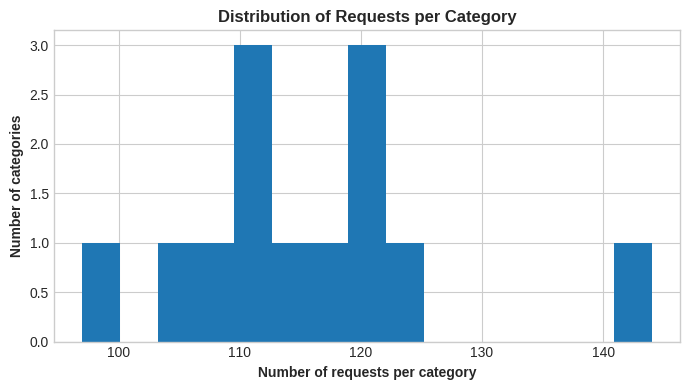

In [ ]:
plt.figure(figsize=(7, 4))
plt.hist(
    requests_by_category["requests_created"],
    bins=15
)

plt.title("Distribution of Requests per Category", fontweight="bold")
plt.xlabel("Number of requests per category", fontweight="bold")
plt.ylabel("Number of categories", fontweight="bold")

plt.tight_layout()
plt.show()

The number of requests by category is fairly evenly distributed.
Most categories are concentrated in the range of approximately 105–125 requests, without sharp skews or dominance of one category. There are also some isolated deviations with lower or higher values, but they do not form separate clusters.
Thus, there is a balanced demand for assistance between different types of needs, without a clear concentration of the load in certain categories.

### **3.4.2. Request vs Offer by help category**

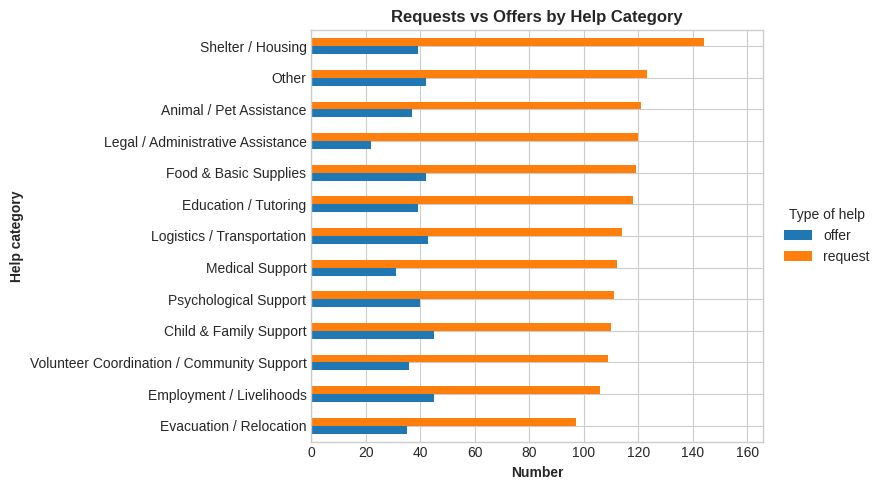

In [ ]:
# Merge category names
df = help_df.merge(
    help_categories_df,
    left_on = 'category_id',
    right_on = 'id',
    how = 'left'
)

# Aggregate data
category_kind_counts = (
    df.groupby(['category', 'kind'])
      .size()
      .unstack(fill_value=0)
      .sort_values(by='request', ascending=True)
)

# Plot style
plt.style.use("seaborn-v0_8-whitegrid")

# Plot
fig, ax = plt.subplots(figsize=(9, 5))

category_kind_counts.plot(kind="barh", ax=ax)

ax.set_xlabel("Number", fontweight="bold")
ax.set_ylabel("Help category", fontweight="bold")
ax.set_title("Requests vs Offers by Help Category", fontweight="bold")

max_value = category_kind_counts.max().max()
ax.set_xlim(0, max_value * 1.15)

ax.legend(
    title="Type of help",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)

plt.tight_layout()
plt.show()

In all categories, the number of requests for assistance significantly exceeds the supply, especially in the housing, legal, medical, and food sectors, indicating the greatest shortage of support there.

### **3.4.3. Demand–Supply Gap by Help Category**

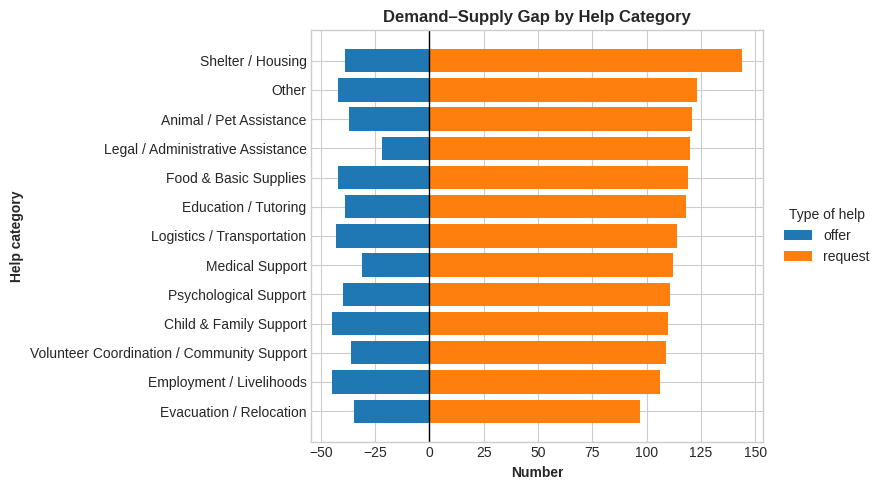

In [ ]:
import matplotlib.pyplot as plt

div_df = category_kind_counts.copy()
div_df["offer_neg"] = -div_df["offer"]

fig, ax = plt.subplots(figsize=(9, 5))

ax.barh(div_df.index, div_df["offer_neg"], label="offer")
ax.barh(div_df.index, div_df["request"], label="request")

ax.set_xlabel("Number", fontweight="bold")
ax.set_ylabel("Help category", fontweight="bold")
ax.set_title("Demand–Supply Gap by Help Category", fontweight="bold")

ax.axvline(0, color="black", linewidth=1)

ax.legend(
    title="Type of help",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)

plt.tight_layout()
plt.show()

There is a persistent gap between demand and supply in all categories, meaning that there are significantly more requests for assistance than opportunities to help. The greatest shortages are observed in housing, food, legal and medical support, which are directly related to the military operations in Ukraine.

### **3.4.4. Successful completion of help requests by category**

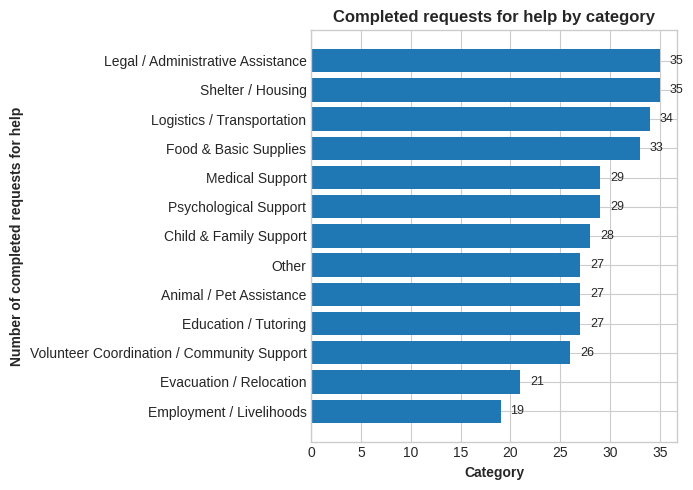

In [ ]:
# Successful helps = completed requests = done
done_by_category = (
    help_df[
        (help_df['kind'] == 'request') &
        (help_df['status'] == 'done')
    ]
    .groupby('category_id')
    .size()
    .reset_index(name='done_helps')
)

# Join category names
done_by_category = done_by_category.merge(
    help_categories_df,
    left_on='category_id',
    right_on='id',
    how='left'
)

done_by_category_sorted = done_by_category.sort_values(
    'done_helps',
    ascending=True
)

plt.figure(figsize=(7,5))

plt.barh(
    done_by_category_sorted['category'],
    done_by_category_sorted['done_helps']
)

for i, value in enumerate(done_by_category_sorted['done_helps']):
    plt.text(
        value + 1,
        i,
        str(value),
        va='center',
        fontsize=9
    )

plt.title('Completed requests for help by category', fontweight="bold")
plt.xlabel('Category', fontweight="bold")
plt.ylabel('Number of completed requests for help', fontweight="bold")

plt.tight_layout()
plt.show()

The largest number of completed requests for assistance that correspond to the status 'done' fall on the Legal, Housing and Logistics sectors, while Employment and Evacuation have the fewest completed requests, indicating the complexity of implementing assistance in these areas.

### **3.4.5. Number of new requests for help by category**

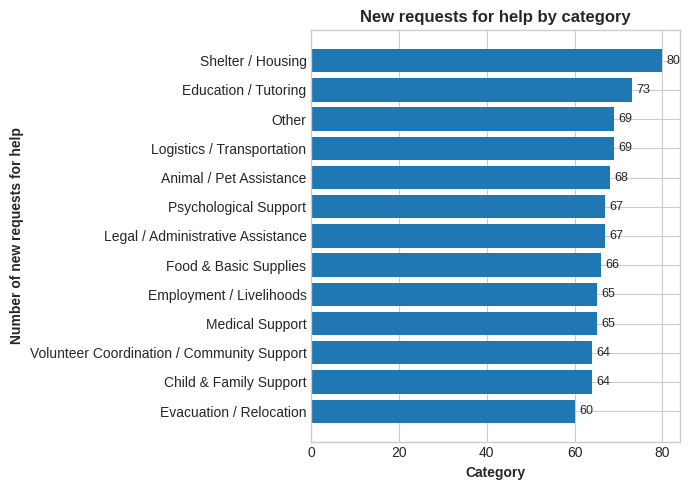

In [ ]:
# Successful helps = completed requests = new
new_by_category = (
    help_df[
        (help_df['kind'] == 'request') &
        (help_df['status'] == 'new')
    ]
    .groupby('category_id')
    .size()
    .reset_index(name='new_helps')
)

# Join category names
new_by_category = new_by_category.merge(
    help_categories_df,
    left_on='category_id',
    right_on='id',
    how='left'
)

new_by_category_sorted = new_by_category.sort_values(
    'new_helps',
    ascending=True
)

plt.figure(figsize=(7,5))

plt.barh(
    new_by_category_sorted['category'],
    new_by_category_sorted['new_helps']
)

for i, value in enumerate(new_by_category_sorted['new_helps']):
    plt.text(
        value + 1,
        i,
        str(value),
        va='center',
        fontsize=9
    )

plt.title('New requests for help by category', fontweight="bold")
plt.xlabel('Category', fontweight="bold")
plt.ylabel('Number of new requests for help', fontweight="bold")

plt.tight_layout()
plt.show()

The largest number of new requests for assistance is in the areas of housing, education, and logistics. Relatively lower but still stable demand is observed in the areas of evacuation and family support, indicating a fairly broad spectrum of needs.

### **3.4.6.Number of Help Requests in Progress by Category**

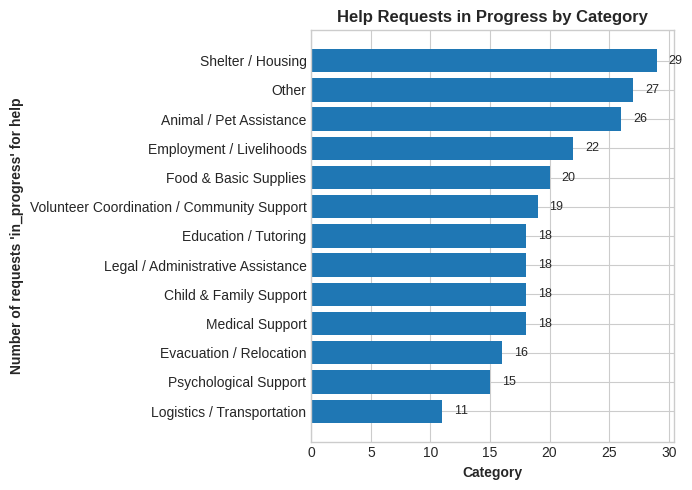

In [ ]:
# Successful helps = completed requests = in_progress
in_progress_by_category = (
    help_df[
        (help_df['kind'] == 'request') &
        (help_df['status'] == 'in_progress')
    ]
    .groupby('category_id')
    .size()
    .reset_index(name='in_progress_helps')
)

# Join category names
in_progress_by_category = in_progress_by_category.merge(
    help_categories_df,
    left_on='category_id',
    right_on='id',
    how='left'
)

in_progress_by_category_sorted = in_progress_by_category.sort_values(
    'in_progress_helps',
    ascending=True
)

plt.figure(figsize=(7,5))

plt.barh(
    in_progress_by_category_sorted['category'],
    in_progress_by_category_sorted['in_progress_helps']
)

for i, value in enumerate(in_progress_by_category_sorted['in_progress_helps']):
    plt.text(
        value + 1,
        i,
        str(value),
        va='center',
        fontsize=9
    )

plt.title("Help Requests in Progress by Category", fontweight="bold")
plt.xlabel('Category', fontweight="bold")
plt.ylabel("Number of requests 'in_progress' for help", fontweight="bold")

plt.tight_layout()
plt.show()

The largest number of 'in_progress' requests is concentrated in the categories of Housing, other needs, and Animal care, indicating their complexity and longer processing times, while Logistics and Psychological support are resolved more quickly.

### **3.4.7. Time to Completion by Category (Days)**

/tmp/ipython-input-3784689123.py:67: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, vert=False, labels=order, showfliers=False)


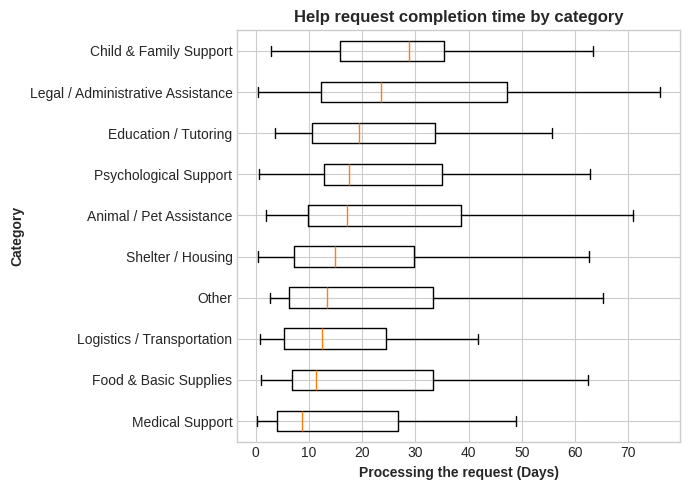

In [ ]:
# Event preparation: created/completed by help_id
events_df["occurred_at"] = pd.to_datetime(events_df["occurred_at"], errors="coerce", utc=True)

created = (
    events_df[events_df["event_name"] == "request_created"]
    .groupby("help_id")["occurred_at"]
    .min()
    .rename("created_at")
)

completed = (
    events_df[events_df["event_name"] == "request_completed"]
    .groupby("help_id")["occurred_at"]
    .min()
    .rename("completed_at")
)

dur = pd.concat([created, completed], axis=1).dropna()
dur["days_to_completion"] = (dur["completed_at"] - dur["created_at"]).dt.total_seconds() / (3600 * 24)

# Remove incorrect values
dur = dur[(dur["days_to_completion"] >= 0) & (dur["days_to_completion"] <= 365)]

dur = dur.reset_index()  # help_id in column

# Add category from help_df
dur = dur.merge(
    help_df[["id", "category_id"]],
    left_on="help_id",
    right_on="id",
    how="left"
)

# Add name of category
dur = dur.merge(
    help_categories_df[["id", "category"]],
    left_on="category_id",
    right_on="id",
    how="left",
    suffixes=("", "_cat")
)

dur["category_label"] = dur["category"].fillna(dur["category_id"].astype(str))

# Top 10 categories by number of completed requests
TOP_CATS = 10
top_cats = (
    dur["category_label"]
    .value_counts()
    .head(TOP_CATS)
    .index
)
plot_df = dur[dur["category_label"].isin(top_cats)].copy()

# Sorting categories by median time
order = (
    plot_df.groupby("category_label")["days_to_completion"]
    .median()
    .sort_values(ascending=True)
    .index
)

data = [plot_df.loc[plot_df["category_label"] == c, "days_to_completion"].values for c in order]

# Box plot
plt.figure(figsize=(7, 5))
plt.boxplot(data, vert=False, labels=order, showfliers=False)
plt.title("Help request completion time by category", fontweight="bold")
plt.xlabel("Processing the request (Days)", fontweight="bold")
plt.ylabel("Category", fontweight="bold")
plt.tight_layout()
plt.show()

The processing time for a request for assistance varies significantly between categories. For example, basic and operational requests (Medical Support, Food & Basic Supplies, Logistics/Transportation) are closed quickly, while complex categories such as Legal/Administrative Assistance have the highest median time, the largest variance, and take significantly longer to complete, which is associated with the need for documents to be processed by different services. In this regard, these categories are key risk areas for service quality, as the risk of long waits for users increases.

### **3.4.8. Cumulative % of requests by category**

In [ ]:
help_categories_df

,id,category
0,1,Evacuation / Relocation
1,2,Medical Support
2,3,Shelter / Housing
3,4,Food & Basic Supplies
4,5,Logistics / Transportation
5,6,Psychological Support
6,7,Child & Family Support
7,8,Legal / Administrative Assistance
8,9,Employment / Livelihoods
9,10,Education / Tutoring


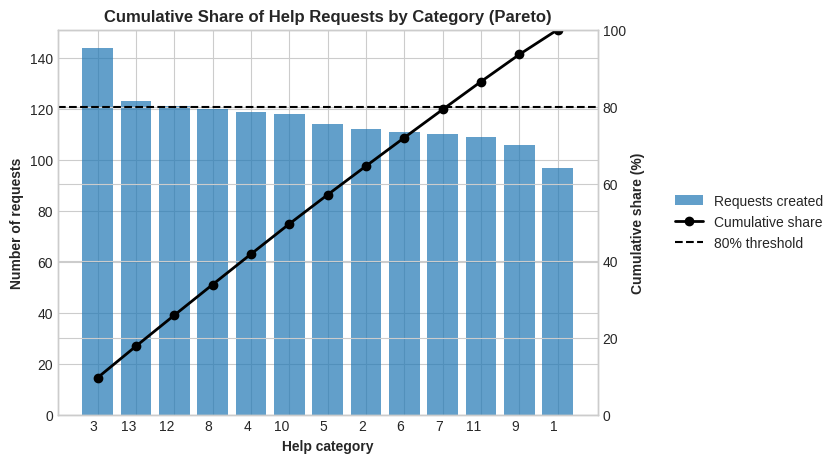

In [ ]:
# Data preparation
pareto_df = (
    requests_by_category
    .sort_values("requests_created", ascending=False)
    .reset_index(drop=True)
)

pareto_df["cumulative_requests"] = pareto_df["requests_created"].cumsum()
total_requests = pareto_df["requests_created"].sum()
pareto_df["cumulative_share"] = pareto_df["cumulative_requests"] / total_requests

fig, ax1 = plt.subplots(figsize=(8, 5))

x = pareto_df.index

# Bars
ax1.bar(
    x,
    pareto_df["requests_created"],
    alpha=0.7,
    label="Requests created"
)
ax1.set_ylabel("Number of requests", fontweight="bold")
ax1.set_xlabel("Help category", fontweight="bold")

ax1.set_xticks(x)
ax1.set_xticklabels(pareto_df["category_id"], rotation=0, ha="right")

# Second axis (Pareto line)
ax2 = ax1.twinx()
ax2.plot(
    x,
    pareto_df["cumulative_share"] * 100,
    marker="o",
    linewidth=2,
    color="black",
    label="Cumulative share"
)

ax2.axhline(
    80,
    linestyle="--",
    linewidth=1.5,
    color="black",
    label="80% threshold"
)
ax2.set_ylabel("Cumulative share (%)", fontweight="bold")
ax2.set_ylim(0, 100)

plt.title("Cumulative Share of Help Requests by Category (Pareto)", fontweight="bold")

# Legend outside on the right
ax2.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="center left",
    bbox_to_anchor=(1.12, 0.5)
)

plt.subplots_adjust(right=0.8)
plt.show()

The Pareto effect is almost absent here.
The queries are distributed fairly evenly across categories - no small group of categories accounts for the majority (80%) of all queries.

### **3.4.9. Analysis of Workload by Category**

The task is to verify whether the average workload by category and the average execution time by category differ.

In [ ]:
# Data preparation
help_df['created_at'] = pd.to_datetime(help_df['created_at'])
help_df['completed_at'] = pd.to_datetime(help_df['completed_at'])

# Daily workload
help_df['created_date'] = help_df['created_at'].dt.date

daily_load = (
    help_df.groupby('created_date')
    .size()
    .reset_index(name='daily_requests')
)

# Taking only completed_at
completed = help_df[help_df['completed_at'].notna()].copy()

# Execution time
completed['resolution_time_days'] = (
    (completed['completed_at'] - completed['created_at'])
    .dt.total_seconds() / 86400
)

completed['created_date'] = completed['created_at'].dt.date

# Joining a workload
completed = completed.merge(
    daily_load,
    on='created_date',
    how='left'
)

Simple aggregate analysis

In [ ]:
category_analysis = (
    completed.groupby('category_id')
    .agg(
        avg_resolution_time=('resolution_time_days', 'mean'),
        avg_daily_workload=('daily_requests', 'mean'),
        number_of_requests=('id', 'count')
    )
    .reset_index()
)

print(category_analysis)

    category_id  avg_resolution_time  avg_daily_workload  number_of_requests
0             1            29.500047           23.827586                  29
1             2            20.855614           22.970588                  34
2             3            20.994064           23.275000                  40
3             4            22.718213           23.871795                  39
4             5            18.822250           22.717949                  39
5             6            23.816295           21.513514                  37
6             7            26.904825           23.000000                  33
7             8            30.483837           23.500000                  40
8             9            24.104719           24.440000                  25
9            10            25.182406           23.718750                  32
10           11            24.096980           22.903226                  31
11           12            22.840366           23.205882                  34

Visualization of average execution time by category

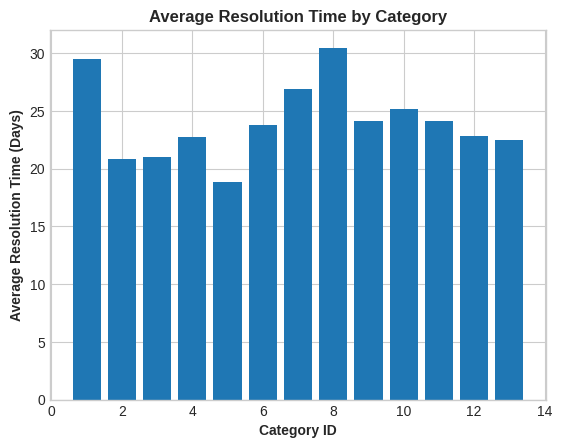

In [ ]:
plt.figure()

plt.bar(
    category_analysis['category_id'],
    category_analysis['avg_resolution_time']
)

plt.xlabel('Category ID', fontweight="bold")
plt.ylabel('Average Resolution Time (Days)', fontweight="bold")
plt.title('Average Resolution Time by Category', fontweight="bold")

plt.show()

The graph shows that the average query execution time ranges from approximately 19 to 31 days. That is, there are categories with the highest time (30–31 days) and with the fastest execution (19–21 days). The difference between the minimum and maximum is about 10–12 days.
So, there is a moderate difference in the average execution time between the categories, which may indicate different complexity of the queries.

Average workload by category

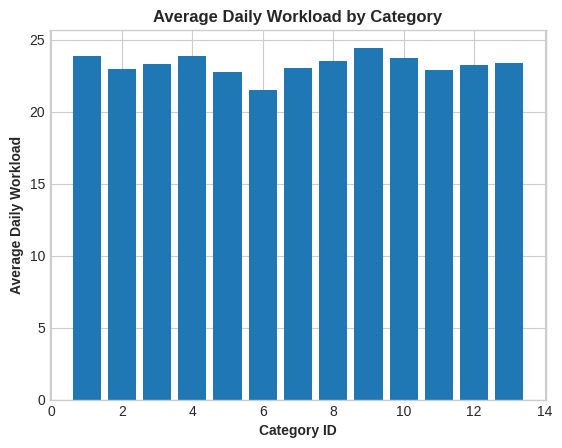

In [ ]:
plt.figure()

plt.bar(
    category_analysis['category_id'],
    category_analysis['avg_daily_workload']
)

plt.xlabel('Category ID', fontweight="bold")
plt.ylabel('Average Daily Workload', fontweight="bold")
plt.title('Average Daily Workload by Category', fontweight="bold")

plt.show()

Workload is almost the same in all categories and the fluctuations are very small (21.5–24.5). No category has a significantly higher workload. Therefore, the workload distribution between categories is relatively even. There is no category that consistently receives significantly more applications.

Category-level (avg_daily_workload, avg_resolution_time) dependency checking

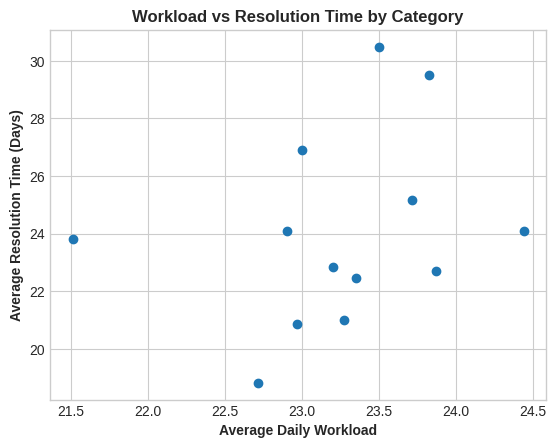

In [ ]:
plt.figure()

plt.scatter(
    category_analysis['avg_daily_workload'],
    category_analysis['avg_resolution_time']
)

plt.xlabel('Average Daily Workload', fontweight="bold")
plt.ylabel('Average Resolution Time (Days)', fontweight="bold")
plt.title('Workload vs Resolution Time by Category', fontweight="bold")

plt.show()

It is noticeable from the graph that the points are arranged randomly and do not have a clear upward or downward trend. Categories with higher workload do not have consistently higher execution times. Therefore, visually there is no relationship between workload and execution time at the category level.

While the average resolution time varies by category, the daily workload remains relatively consistent. There was no clear correlation between workload and resolution time, suggesting that the differences in processing times are likely due to the complexity of the requests.

## **3.5. Regional activity by city**

### **3.5.1. Number of requests for help by city**

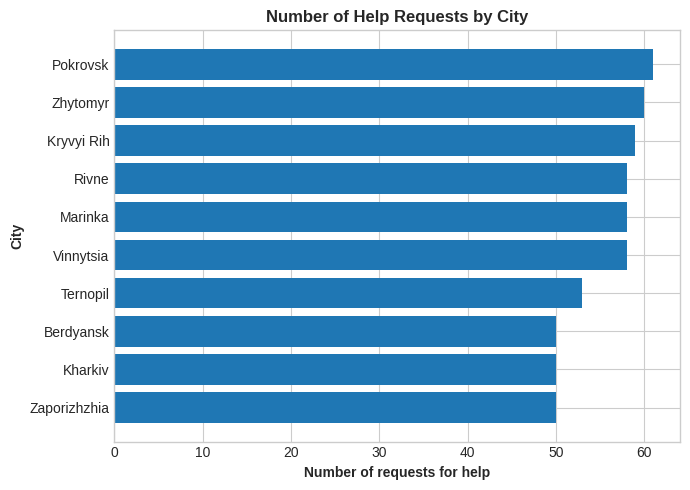

In [ ]:
# Filter help requests
requests = events_df[events_df["event_name"] == "request_created"]

# Count requests per city
requests_by_city = (
    requests.groupby("city")
    .size()
    .rename("requests_count")
    .sort_values(ascending=False)
)

# print(requests_by_city)

TOP_N = 10

top_cities = requests_by_city.head(TOP_N)

plt.figure(figsize=(7, 5))
plt.barh(top_cities.index, top_cities.values)
plt.gca().invert_yaxis()
plt.title("Number of Help Requests by City",  fontweight="bold")
plt.xlabel("Number of requests for help",  fontweight="bold")
plt.ylabel("City",  fontweight="bold")
plt.tight_layout()
plt.show()

The largest number of requests for assistance was recorded in Pokrovsk, Zhytomyr, and Kryvyi Rih, with a slightly lower level of requests in Zaporizhia, Kharkiv, and Berdyansk. Thus, it is clear from the graph that there is a significant demand for assistance in various cities of Ukraine, with a wide geographical distribution of needs by city.

### **3.5.2. Requests vs Completed Helps by City**

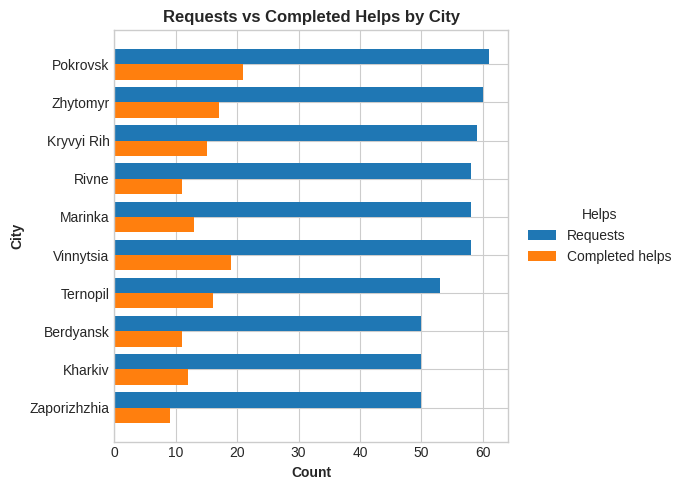

In [ ]:
# Requests
req = events_df[events_df["event_name"] == "request_created"]
cmp = events_df[events_df["event_name"] == "request_completed"]

req_city = req.groupby("city").size().rename("requests")
cmp_city = cmp.groupby("city").size().rename("completed")

city_compare = pd.concat([req_city, cmp_city], axis=1).fillna(0)
city_compare["requests"] = city_compare["requests"].astype(int)
city_compare["completed"] = city_compare["completed"].astype(int)

TOP_N = 10

top = (
    city_compare
    .sort_values("requests", ascending=False)
    .head(TOP_N)
)

# Sort by number of requests
top = top.sort_values("requests", ascending=False)

# Bar positions
y = range(len(top))

plt.figure(figsize=(7, 5))

plt.barh(
    [i - 0.2 for i in y],
    top["requests"],
    height=0.4,
    label="Requests"
)

plt.barh(
    [i + 0.2 for i in y],
    top["completed"],
    height=0.4,
    label="Completed helps"
)

plt.yticks(list(y), top.index)
plt.xlabel("Count", fontweight="bold")
plt.ylabel("City", fontweight="bold")
plt.title("Requests vs Completed Helps by City", fontweight="bold")

plt.gca().invert_yaxis()

plt.legend(
    title='Helps',
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

plt.tight_layout()
plt.show()

In all cities, the number of requests for assistance significantly exceeds the number of requests processed, indicating an existing shortage of resources and the need to increase the involvement of volunteers at the local level.

### **3.5.3. Heatmap of Help Requests by City and Category**

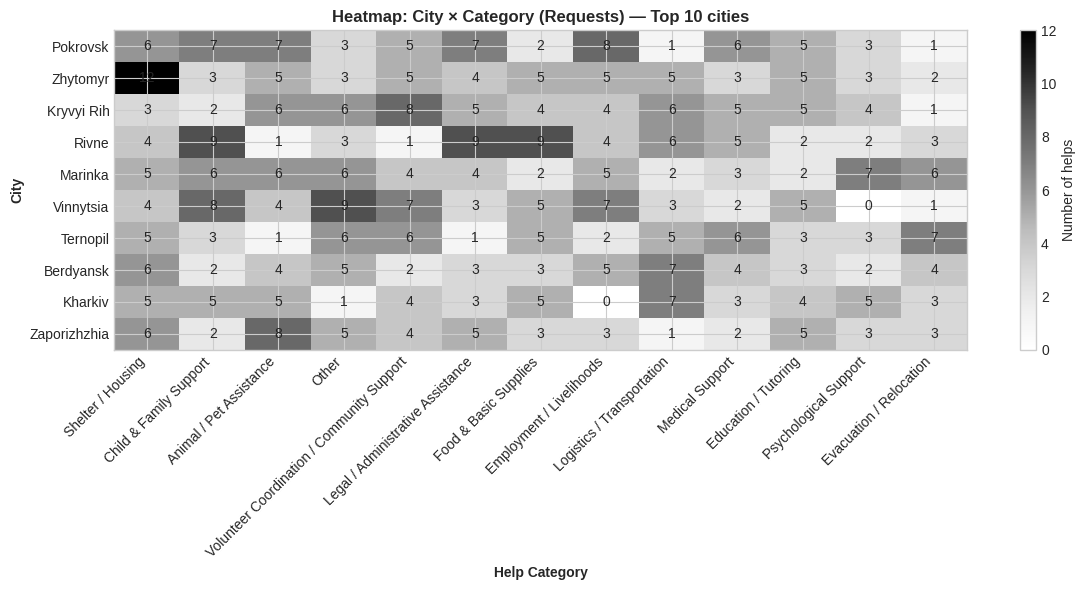

In [ ]:
help_with_cat = help_df.merge(
    help_categories_df[["id", "category"]],
    left_on="category_id",
    right_on="id",
    how="left",
    suffixes=("", "_cat")
)

def make_pivot(df, top_n=10):
    pivot = pd.pivot_table(
        df,
        index="city",
        columns="category",
        values="category_id",
        aggfunc="count",
        fill_value=0
    )
    # TOP cities by the amount of requests for help created
    pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).head(top_n).index]

    pivot = pivot[pivot.sum(axis=0).sort_values(ascending=False).index]
    return pivot

def plot_heatmap_with_numbers(pivot, title):
    plt.figure(figsize=(12, 6))
    ax = plt.gca()

    im = ax.imshow(pivot.values, aspect="auto")

    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)

    ax.set_xlabel("Help Category", fontweight="bold")
    ax.set_ylabel("City", fontweight="bold")
    ax.set_title(title, fontweight="bold")

    # Colorbar
    plt.colorbar(im, ax=ax, label="Number of helps")

    # Adding numbers to cells
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            val = int(pivot.iat[i, j])
            ax.text(j, i, str(val), ha="center", va="center")

    plt.tight_layout()
    plt.show()

TOP_N = 10

# Request heatmap
req_df = help_with_cat[help_with_cat["kind"] == "request"]
pivot_req = make_pivot(req_df, top_n=TOP_N)
plot_heatmap_with_numbers(pivot_req, f"Heatmap: City × Category (Requests) — Top {TOP_N} cities")

The heat map shows that requests for assistance vary significantly across cities and categories. Yes, in each city there are several dominant areas of requests (including housing, logistics, administrative and medical assistance), which indicates the uneven and locally specific nature of needs.

### **3.5.4. Heatmap of Help Offers by City and Category**

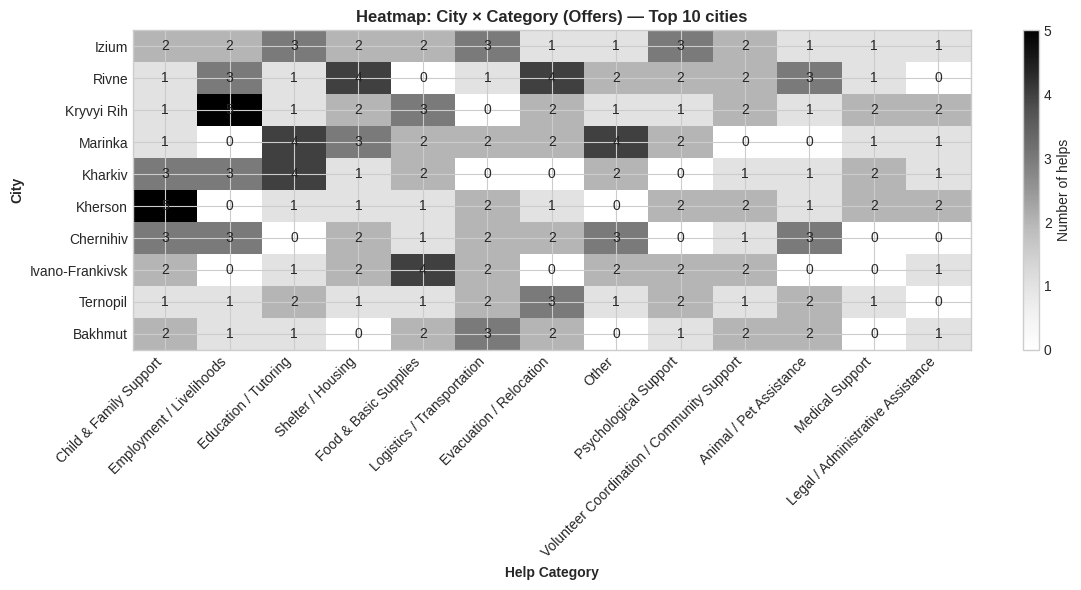

In [ ]:
# Offer heatmap
offer_df = help_with_cat[help_with_cat["kind"] == "offer"]
pivot_offer = make_pivot(offer_df, top_n=TOP_N)
plot_heatmap_with_numbers(pivot_offer, f"Heatmap: City × Category (Offers) — Top {TOP_N} cities")

Assistance offers are fairly evenly distributed across cities, with no sharply dominant categories. The most common categories include basic support, food/goods, and logistics/transport, with notable psychological and volunteer support. On the other hand, medical and legal/administrative offers are less well represented and unevenly distributed, depending on the city.

### **3.5.5. Cities with High Demand and Low Number of Volunteers**

In [ ]:
# Created requests by city
demand = (
    events_df[(events_df["kind"] == "request") & (events_df["event_name"] == "request_created")]
    .groupby("city")["help_id"]
    .nunique()
    .rename("requests_created")
    .reset_index()
)

# Unique volunteers who took requests in cities
supply = (
    events_df[
        (events_df["kind"] == "request") &
        (events_df["event_name"] == "request_take_succeeded") &
        (events_df["user_role"] == "volunteer")
    ]
    .groupby("city")["user_id"]
    .nunique()
    .rename("active_volunteers")
    .reset_index()
)

# Imbalance indicators
city = demand.merge(supply, on="city", how="left").fillna({"active_volunteers": 0})
city["active_volunteers"] = city["active_volunteers"].astype(int)

# Requests per volunteer
city["requests_per_active_volunteer"] = np.where(
    city["active_volunteers"] > 0,
    city["requests_created"] / city["active_volunteers"],
    np.inf
)

# Automatic rule "high demand + low volunteers"
# High demand = top 25% on demand
demand_threshold = city["requests_created"].quantile(0.75)
# Low supply = bottom 25% by active volunteers
supply_threshold = city["active_volunteers"].quantile(0.25)

city["high_demand_low_volunteers"] = (
    (city["requests_created"] >= demand_threshold) &
    (city["active_volunteers"] <= supply_threshold)
)

# Result: list of cities with imbalance
result = (
    city[city["high_demand_low_volunteers"]]
    .sort_values(["requests_created", "active_volunteers"], ascending=[False, True])
)

print("Threshold values:")
print(f"High demand threshold (75p): {demand_threshold:.0f} created requests")
print(f"Low volunteers threshold (25p): {supply_threshold:.0f} active volunteers")

print("\nCities with high demand and low number of active volunteers:")
print(result[["city", "requests_created", "active_volunteers", "requests_per_active_volunteer"]])

Threshold values:
High demand threshold (75p): 50 created requests
Low volunteers threshold (25p): 16 active volunteers

Cities with high demand and low number of active volunteers:
        city  requests_created  active_volunteers  \
1  Berdyansk                50                 16   

   requests_per_active_volunteer  
1                          3.125  


## **3.6. Request Lifecycle**

### **3.6.1. Help Request Lifecycle Funnel**

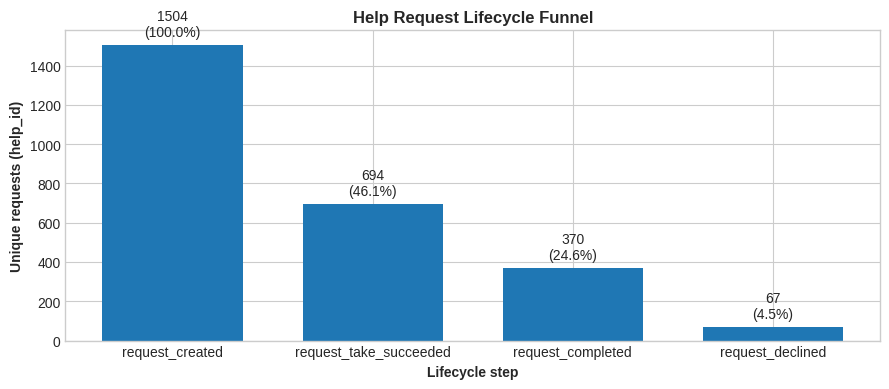

In [ ]:
import numpy as np

ID_COL = "help_id"
TIME_COL = "occurred_at"

events_df[TIME_COL] = pd.to_datetime(events_df[TIME_COL], errors="coerce", utc=True)

# Only take request events
req_events = events_df[events_df["kind"] == "request"].copy()

STEPS = [
    "request_created",
    "request_take_succeeded",
    "request_completed",
    "request_declined"
]

available = set(req_events["event_name"].dropna().unique())
steps = [s for s in STEPS if s in available]

step_ids = {}
for s in steps:
    step_ids[s] = set(
        req_events.loc[req_events["event_name"] == s, ID_COL]
        .dropna()
        .unique()
    )

if "request_created" not in step_ids or len(step_ids["request_created"]) == 0:
    raise ValueError("Не знайдено request_created або порожньо (немає бази для funnel).")

base = step_ids["request_created"]

labels, counts, conv_from_created = [], [], []
for s in steps:
    reached = base & step_ids[s]
    labels.append(s)
    counts.append(len(reached))
    conv_from_created.append(len(reached) / len(base))

#P lotting
x = np.arange(len(labels))

plt.figure(figsize=(9, 4))
bars = plt.bar(x, counts, width=0.7, align="center")

plt.xticks(x, labels, rotation=0, ha="center")
plt.xlabel("Lifecycle step", fontweight="bold")
plt.ylabel("Unique requests (help_id)", fontweight="bold")
plt.title("Help Request Lifecycle Funnel", fontweight="bold")

y_pad = max(counts) * 0.02 if max(counts) else 1
for b, n, p in zip(bars, counts, conv_from_created):
    plt.text(
        b.get_x() + b.get_width() / 2,
        b.get_height() + y_pad,
        f"{n}\n({p:.1%})",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

The graph shows the life cycle of requests on the web platform. 1504 requests were created, of which only 46% were taken into work, and 25% reached completion. The largest dropout is observed at the stage of transition from creating to taking a request, which is the main "bottleneck" in the web service and explains the need to motivate existing volunteers and increase the involvement of new ones. There are a few rejected requests (~4.5%), so the problem is most likely a lack of resources/speed of taking requests into work, and not the quality of the requests themselves.

### **3.6.2. Help Offer Lifecycle Funnel**

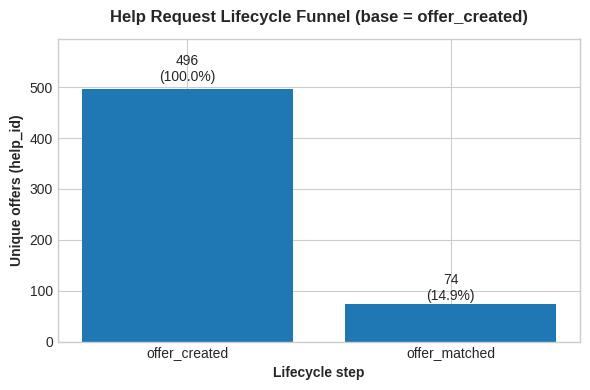

In [ ]:

ID_COL = "help_id"
TIME_COL = "occurred_at"

events_df[TIME_COL] = pd.to_datetime(events_df[TIME_COL], errors="coerce", utc=True)

# Only take offer events
offer_events = events_df[events_df["kind"] == "offer"].copy()

# Lifecycle steps for offers
STEPS = [
    # "offer_form_started",
    # "offer_form_submitted",
    "offer_created",
    "offer_matched",
]

available = set(offer_events["event_name"].dropna().unique())
steps = [s for s in STEPS if s in available]

# Multiple help_id for each step
step_ids = {}
for s in steps:
    step_ids[s] = set(
        offer_events.loc[offer_events["event_name"] == s, ID_COL]
        .dropna()
        .unique()
    )

# Funnel base — usually offer_created
BASE_STEP = "offer_created" if "offer_created" in step_ids else steps[0]
if BASE_STEP not in step_ids or len(step_ids[BASE_STEP]) == 0:
    raise ValueError(f"No base step found {BASE_STEP} or it is empty (there is no base for the funnel).")

base = step_ids[BASE_STEP]

# We calculate count and conversion relative to base
labels, counts, conv_from_base = [], [], []
for s in steps:
    reached = base & step_ids[s]
    labels.append(s)
    counts.append(len(reached))
    conv_from_base.append(len(reached) / len(base))

plt.figure(figsize=(6, 4))
bars = plt.bar(range(len(counts)), counts)

plt.xticks(range(len(counts)), labels)
plt.xlabel("Lifecycle step", fontweight="bold")
plt.ylabel(f"Unique offers ({ID_COL})", fontweight="bold")

plt.title(
    f"Help Request Lifecycle Funnel (base = {BASE_STEP})",
    fontweight="bold",
    pad=12
)

max_count = max(counts)
plt.ylim(0, max_count * 1.2)

for b, n, p in zip(bars, counts, conv_from_base):
    plt.text(
        b.get_x() + b.get_width() / 2,
        b.get_height() * 1.02,
        f"{n}\n({p:.1%})",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

The graph shows 496 created offers of assistance, of which only 74 were closed, or about 15%. This indicates a low conversion of offers into real use, meaning there is likely a gap between the amount of assistance offered and the amount actually needed, or attention should be paid to the visibility of offers.

# **Conclusion**

The analysis considered the full life cycle of requests for help on the Wings of Help web platform, from the moment the user starts filling out the form to the request being processed by a volunteer. The formed set of metrics enabled a comprehensive assessment of the need for help, the effectiveness of the matching process, the speed of volunteers' responses, the quality of request execution, as well as the level of workload on volunteers.  

The analysis of metrics related to the creation of requests (request creation conversion rate, form abandonment rate) showed that users generally successfully complete the request creation process. At the same time, the rejection rate differs significantly depending on the category of assistance. The likely reason for such differences is the increased complexity of the request creation process and the need for detailed justification of the need in individual categories, in particular those related to evacuation and housing.
A stable flow of created requests for help was recorded on the web platform, which indicates the proper performance of the main functions, namely, user engagement, the formation of requests for help, and the rapid processing of requests by volunteers.  

Analysis of the matching process and the speed of response of volunteers showed that the matching of requests with volunteers is functional, but not fully optimized. A significant proportion of created requests are not accepted for processing, and a significant number of requests are in the “new” status for more than 48 hours. The average time to take a request into work is about 1.5 days, which can be critical for certain types of assistance.  

The results obtained indicate not a shortage of volunteers as such, but rather the presence of a number of operational factors, which include the uneven distribution of requests between categories of assistance, differences in the complexity of requests for volunteers, and certain limitations in the search, filtering, and display mechanisms for requests.  

Metrics characterizing the execution of requests and their duration made it possible to assess the quality and time parameters of providing assistance. More than half of the requests that were accepted for processing are successfully completed, which indicates a sufficiently high level of responsibility and involvement of volunteers. At the same time, the average time for completing a request is relatively long (approximately 20 days).

Analysis of median values ​​and percentiles revealed an asymmetric distribution of the duration of execution, which indicates the presence of a part of requests that require significantly more time compared to typical scenarios.
Analysis of requests by category confirmed that different types of assistance have fundamentally different needs. Some requests are closed quickly and stably, while others require long-term, phased, or comprehensive support. In this context, the use of medians and percentiles turned out to be more informative compared to the analysis of only average values.  

Analysis of the volunteer load, both in general and by category, showed that it is distributed relatively evenly. On average, one volunteer processes 4–5 requests over the entire observation period, with only a small proportion of volunteers having a significantly higher load. The analysis by category did not reveal any situations in which certain types of assistance are critically dependent on a narrow circle of volunteers. This gives grounds to assert that there is currently no systemic risk of volunteer burnout, and the platform is not critically dependent on individual participants.

Overall, the Wings of Help web platform demonstrates a healthy operational structure, characterized by the following features:  
 - a stable process of creating requests for assistance;
 - active involvement of volunteers;
 - bringing the majority of requests accepted for work to completion;
 - relatively even distribution of the workload between volunteers.

At the same time, the analysis allowed us to identify key areas for further improvement of the platform, in particular:  
 - reducing the waiting time for a request to be processed;
 - reducing the share of unprocessed requests;
 - optimizing the user experience and the process of creating requests in complex assistance categories;
 - increasing transparency and clarity in managing user expectations regarding the duration of assistance.    

Therefore, the analysis conducted allowed not only to characterize the current state of the Wings of Help web platform, but also to form a solid analytical basis for making product and operational decisions aimed at increasing the efficiency and long-term sustainability of the aid delivery system.

# **4. Creating dashboards**

## **4.1. Dashboard in Tableau**

This dashboard provides a comprehensive analytical overview of the Wings of Help platform, focusing on user growth, engagement, operational efficiency, and supply-demand balance between requests and offers.
It is designed to support product and operational decision-making by tracking platform performance across acquisition, activation, engagement, and fulfillment stages.


Dashboard structure:
- Block 1. KPI Summary.  
- Block 2. User & Request Distribution Overview.  
- Block 3. User growth and cumulative growth analysis.  
- Block 4. Geographic Distribution.  
- Block 5. Category-Level Supply vs Demand.  

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
from PIL import Image
import matplotlib.pyplot as plt

(np.float64(-0.5), np.float64(1498.5), np.float64(1748.5), np.float64(-0.5))

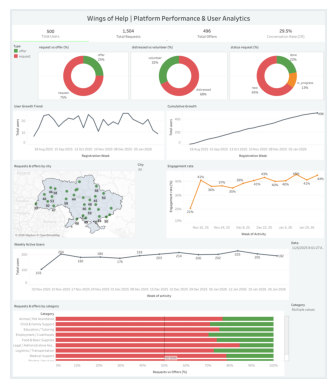

In [5]:
img = Image.open('/content/drive/My Drive/Team Project #211/SP4/Wings of Help Tableau.png')
plt.imshow(img)
plt.axis("off")

[Link to dashboard in Tableau Public](https://public.tableau.com/app/profile/oksana.olar/viz/WingsofHelpAnalyticsMVP/WingsofHelpPlatformPerformanceUserAnalytics)

[Link to dashboard structure and report](https://docs.google.com/document/d/1YSGfG6Q_suBsq-ZqdDYUU1btYVzp1ffhKQPFzbhEvKw/edit?usp=sharing)

## **4.2. Dashboard in Power BI**

This dashboard is designed for a comprehensive analysis of the effectiveness of the Wings of Help web platform. It allows you to assess the balance between demand and supply of assistance, the level of coverage of requests by volunteers, the speed of response to requests, and the overall operational effectiveness of the case processing process. The use of key KPIs and analytical visualizations allows you to identify bottlenecks in the platform's work, identify risk areas, and formulate management recommendations for improving the quality of the web service.

Dashboard structure:

Block 1. Platform Health Overview (KPI Cards).  
Block 2. Process Efficiency (KPI Cards).  
Block 3. Service Responsiveness (KPI Cards).   
Block 4. Supply vs Demand Gap.  
Block 5. Life Cycle Analysis (Funnel).  

(np.float64(-0.5), np.float64(1126.5), np.float64(728.5), np.float64(-0.5))

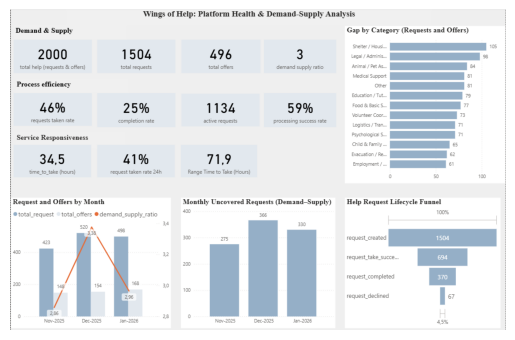

In [7]:
img = Image.open('/content/drive/My Drive/Team Project #211/SP4/Wings of Help Power BI.png')
plt.imshow(img)
plt.axis("off")

[Link to dashboard structure and report](https://docs.google.com/document/d/1YSGfG6Q_suBsq-ZqdDYUU1btYVzp1ffhKQPFzbhEvKw/edit?tab=t.qznv95tr8w6q)